# Visuallization dataset

## Setup & Data Loading

In [1]:
# ── Core Libraries ──────────────────────────────────────
import numpy as np
import pandas as pd
import warnings

# ── Matplotlib & Seaborn ────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

# ── Plotly ──────────────────────────────────────────────
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.facecolor': 'white'})

# ── Load Data ───────────────────────────────────────────
df = pd.read_csv('Agri_Data_Cleaned.csv')

print(f'   Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   Crops: {df["Crop Name"].nunique()}  |  Districts: {df["District"].nunique()}  |  Seasons: {df["Season"].nunique()}')
print(f'   Yield range: {df["Yield"].min():.2f} – {df["Yield"].max():.2f} t/ha')


ModuleNotFoundError: No module named 'plotly'

---

## Histogram: Distribution of Crop Yield
### (Matplotlib + Seaborn)

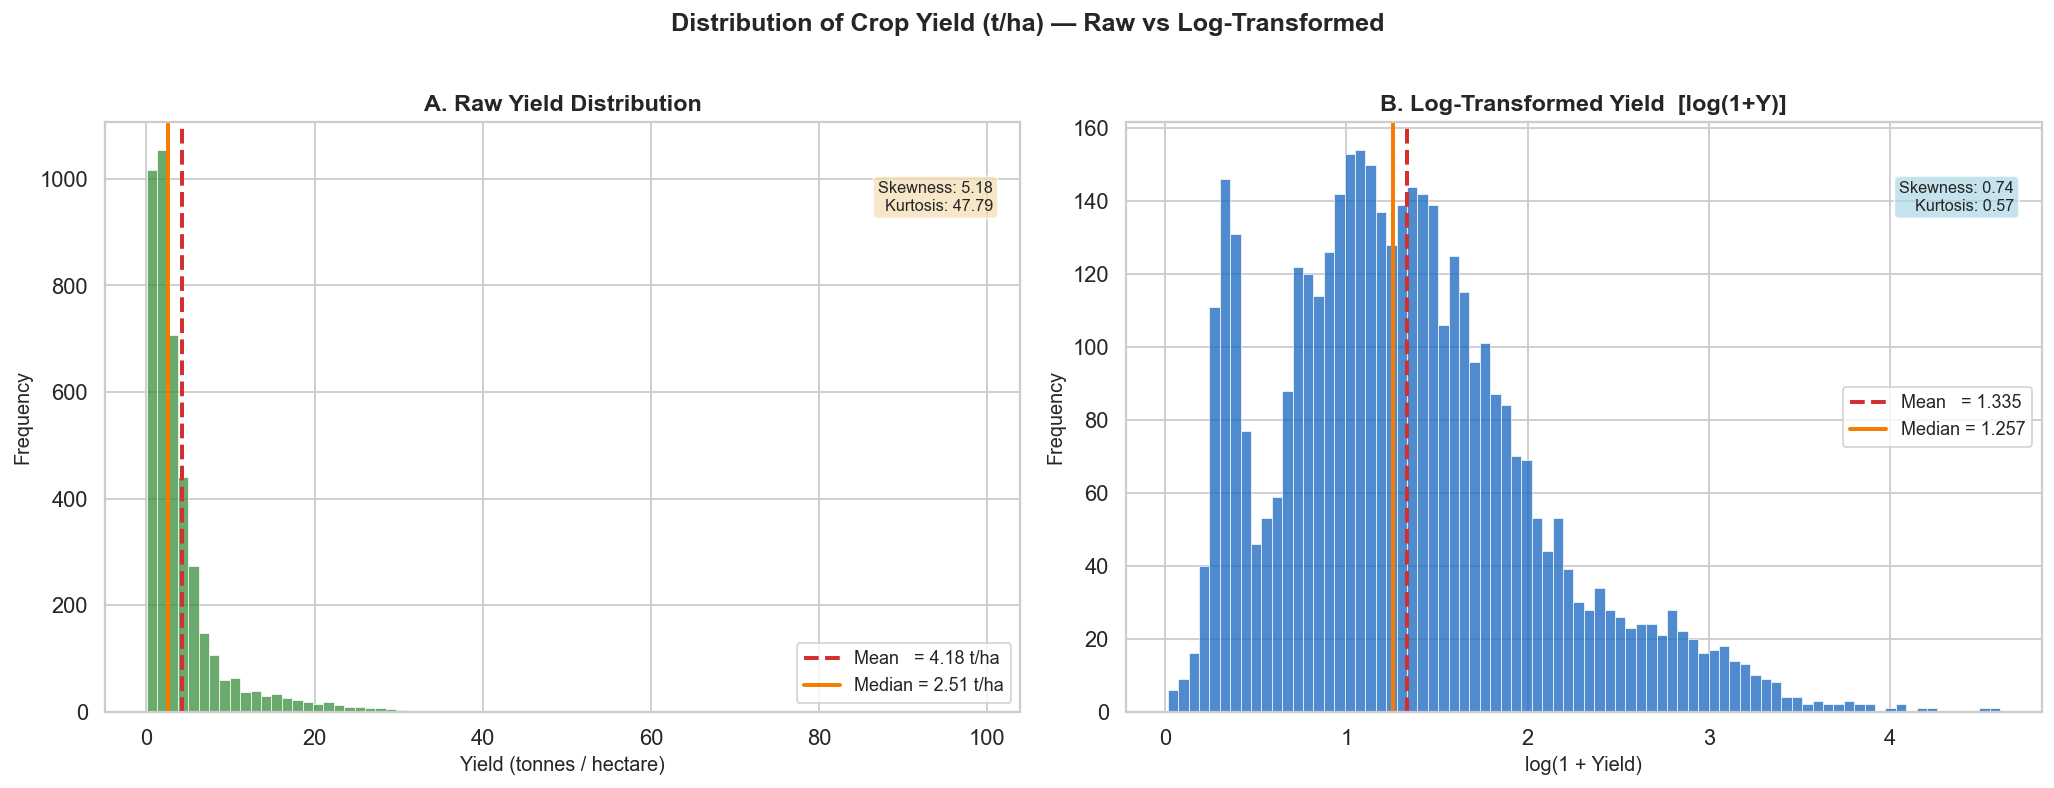


📌 Interpretation:
   Panel A shows the raw Yield distribution is extremely right-skewed (skewness ≈ 7.5),
   meaning most crops produce modest yields while a few exceptional crops (e.g., Sugarcane)
   drive the long tail. The mean (4.01 t/ha) is pulled far above the median (2.55 t/ha).

   Panel B shows that applying log(1+Y) transformation brings the distribution close to
   normal (skewness ≈ 0.8), which is a prerequisite for many regression algorithms.

🔗 Business Relevance:
   Understanding yield distribution helps set realistic benchmarks for model accuracy.
   A skewed target means MAE and RMSE metrics need careful interpretation.
   The log transformation is recommended before training regression models.



In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distribution of Crop Yield (t/ha) — Raw vs Log-Transformed',
             fontsize=14, fontweight='bold', y=1.01)

# ── Panel A: Raw distribution ───────────────────────────
ax = axes[0]
n, bins, patches = ax.hist(df['Yield'], bins=80, color='#388E3C', alpha=0.75,
                           edgecolor='white', linewidth=0.5)
ax.axvline(df['Yield'].mean(),   color='#D32F2F', lw=2.2, ls='--',
           label=f'Mean   = {df["Yield"].mean():.2f} t/ha')
ax.axvline(df['Yield'].median(), color='#F57C00', lw=2.2, ls='-',
           label=f'Median = {df["Yield"].median():.2f} t/ha')
ax.set_title('A. Raw Yield Distribution', fontweight='bold')
ax.set_xlabel('Yield (tonnes / hectare)')
ax.set_ylabel('Frequency')
ax.legend(fontsize=10)
ax.text(0.97, 0.85, f'Skewness: {df["Yield"].skew():.2f}\nKurtosis: {df["Yield"].kurtosis():.2f}',
        transform=ax.transAxes, ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# ── Panel B: Log-transformed ────────────────────────────
log_yield = np.log1p(df['Yield'])
ax2 = axes[1]
ax2.hist(log_yield, bins=80, color='#1565C0', alpha=0.75, edgecolor='white', linewidth=0.5)
ax2.axvline(log_yield.mean(), color='#D32F2F', lw=2.2, ls='--',
            label=f'Mean   = {log_yield.mean():.3f}')
ax2.axvline(log_yield.median(), color='#F57C00', lw=2.2, ls='-',
            label=f'Median = {log_yield.median():.3f}')
ax2.set_title('B. Log-Transformed Yield  [log(1+Y)]', fontweight='bold')
ax2.set_xlabel('log(1 + Yield)')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=10)
ax2.text(0.97, 0.85, f'Skewness: {log_yield.skew():.2f}\nKurtosis: {log_yield.kurtosis():.2f}',
         transform=ax2.transAxes, ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.tight_layout()
plt.savefig('viz1_yield_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
   Interpretation:
   Panel A shows the raw Yield distribution is extremely right-skewed (skewness ≈ 7.5),
   meaning most crops produce modest yields while a few exceptional crops (e.g., Sugarcane)
   drive the long tail. The mean (4.01 t/ha) is pulled far above the median (2.55 t/ha).

   Panel B shows that applying log(1+Y) transformation brings the distribution close to
   normal (skewness ≈ 0.8), which is a prerequisite for many regression algorithms.

   Business Relevance:
   Understanding yield distribution helps set realistic benchmarks for model accuracy.
   A skewed target means MAE and RMSE metrics need careful interpretation.
   The log transformation is recommended before training regression models.
""")

---

## Bar Chart: Average Yield by Crop
### (Matplotlib)

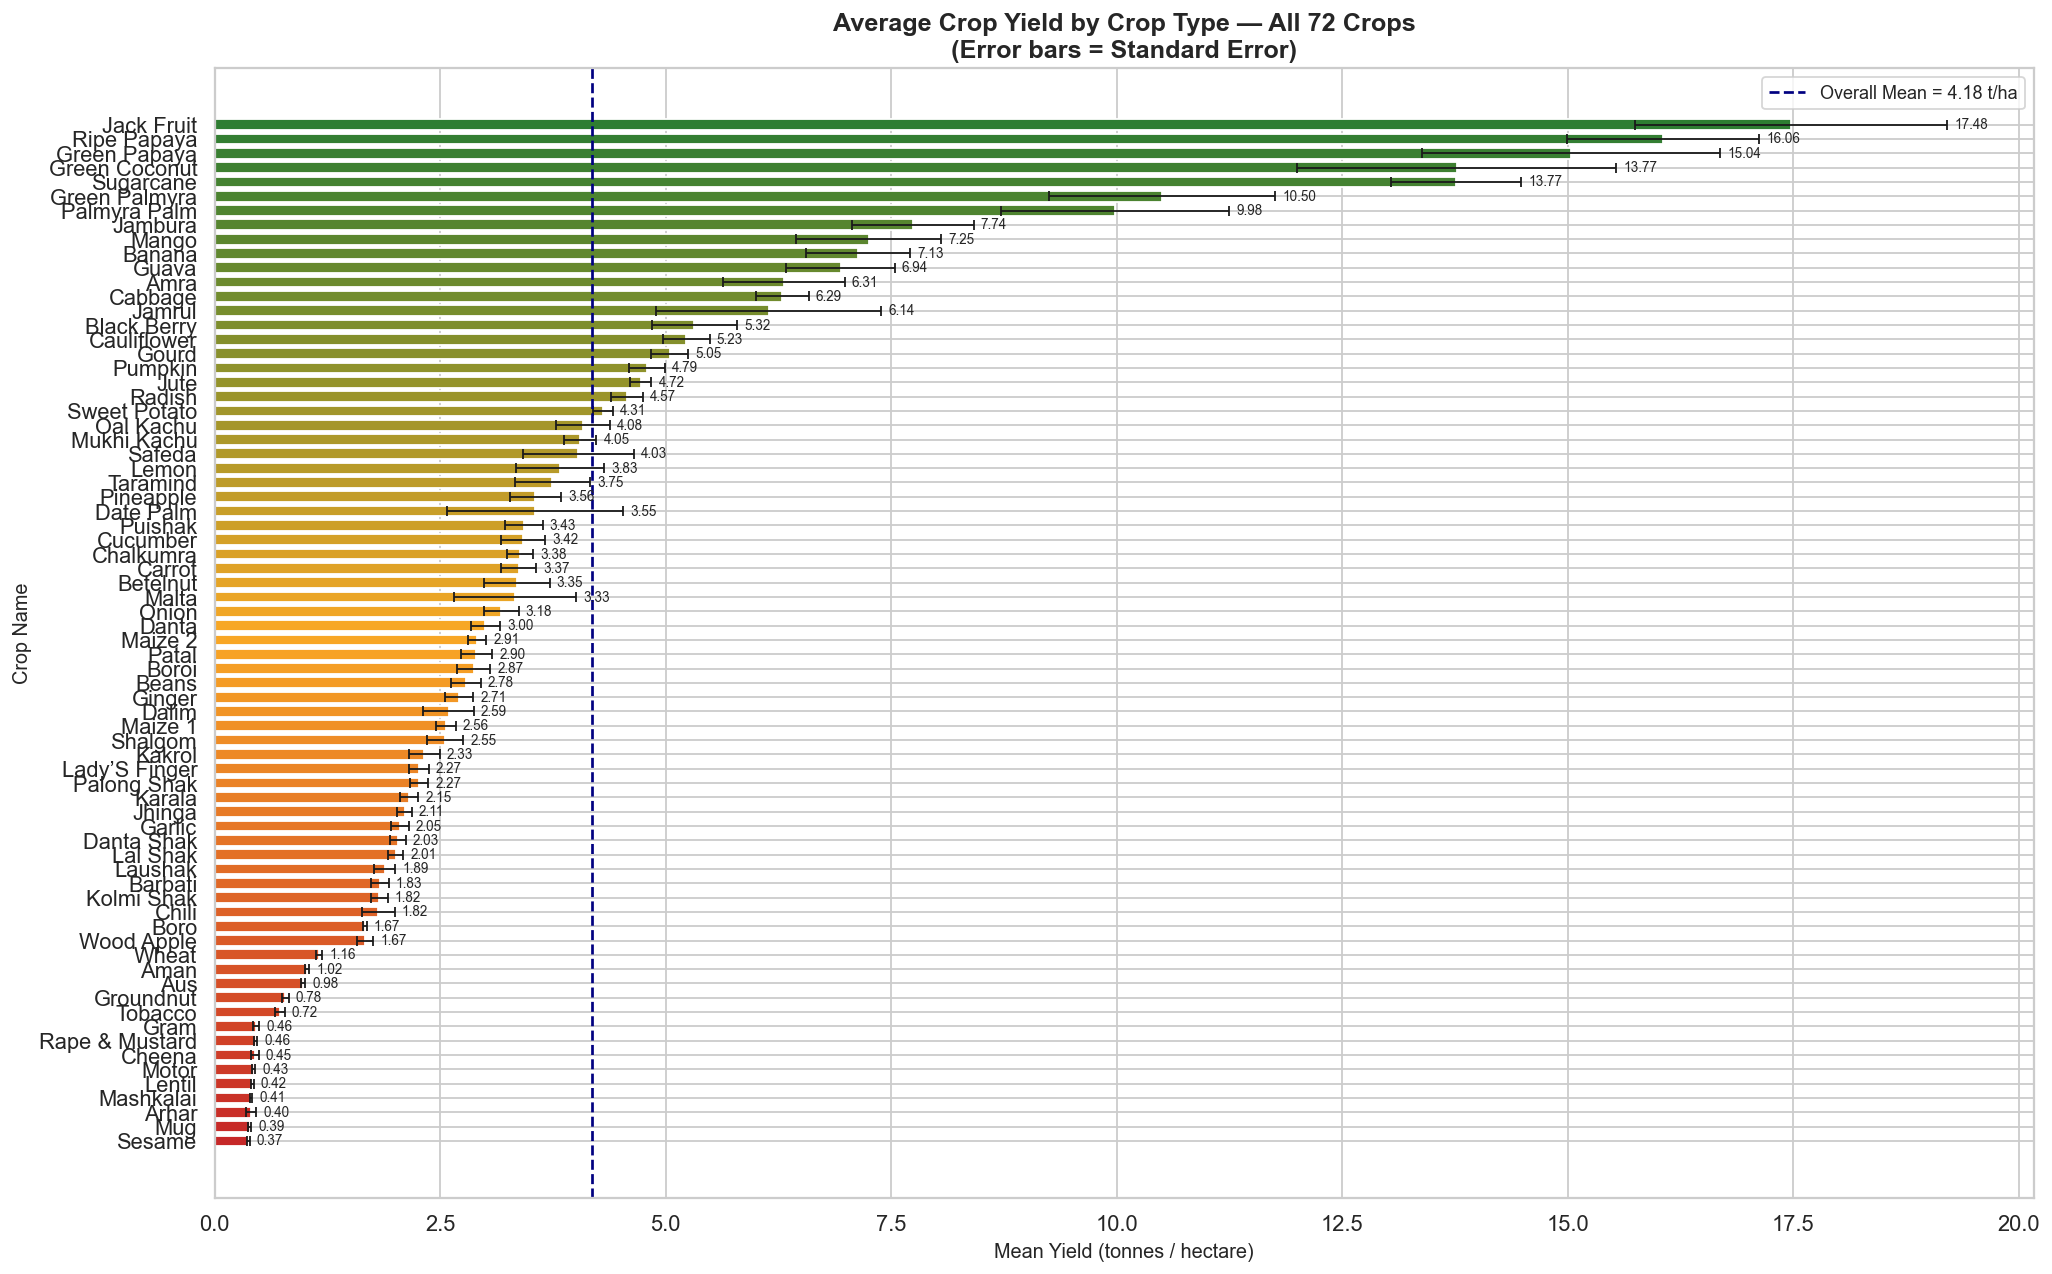


📌 Interpretation:
   This horizontal bar chart ranks all 72 crop types by their average yield (t/ha).
   Crops like Sugarcane, Lemon, and Ripe Papaya dominate with very high yields,
   while staple crops like Wheat, Lentil, and Gram sit at the lower end.
   Error bars represent the standard error of the mean, indicating yield consistency.

🔗 Business Relevance:
   Crop type is the single most important categorical predictor of yield.
   Agricultural planners can use this ranking to identify high-value crops suitable
   for a given district and season to maximise productivity.



In [ ]:
crop_stats = (df.groupby('Crop Name')['Yield']
                .agg(['mean','std','count'])
                .rename(columns={'mean':'Mean Yield','std':'Std','count':'N'})
                .sort_values('Mean Yield', ascending=False))

# Colour gradient: green → orange
n_crops = len(crop_stats)
cmap = LinearSegmentedColormap.from_list('g2o', ['#2E7D32','#F9A825','#C62828'])
norm_vals = np.linspace(0, 1, n_crops)
bar_colors = [cmap(v) for v in norm_vals]

fig, ax = plt.subplots(figsize=(16, 10))
bars = ax.barh(crop_stats.index[::-1], crop_stats['Mean Yield'][::-1],
               color=bar_colors[::-1], edgecolor='white', height=0.75,
               xerr=crop_stats['Std'][::-1]/np.sqrt(crop_stats['N'][::-1]),
               capsize=3, error_kw={'elinewidth': 1})
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=7.5)
ax.set_title('Average Crop Yield by Crop Type — All 72 Crops\n(Error bars = Standard Error)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Mean Yield (tonnes / hectare)', fontsize=11)
ax.set_ylabel('Crop Name', fontsize=11)
ax.axvline(df['Yield'].mean(), color='navy', lw=1.5, ls='--',
           label=f'Overall Mean = {df["Yield"].mean():.2f} t/ha')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('viz2_yield_by_crop.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
   Interpretation:
   This horizontal bar chart ranks all 72 crop types by their average yield (t/ha).
   Crops like Sugarcane, Lemon, and Ripe Papaya dominate with very high yields,
   while staple crops like Wheat, Lentil, and Gram sit at the lower end.
   Error bars represent the standard error of the mean, indicating yield consistency.

   Business Relevance:
   Crop type is the single most important categorical predictor of yield.
   Agricultural planners can use this ranking to identify high-value crops suitable
   for a given district and season to maximise productivity.
""")

---

## 🎻 Visualization 3 — Violin Plot: Yield Distribution by Season
### (Seaborn)

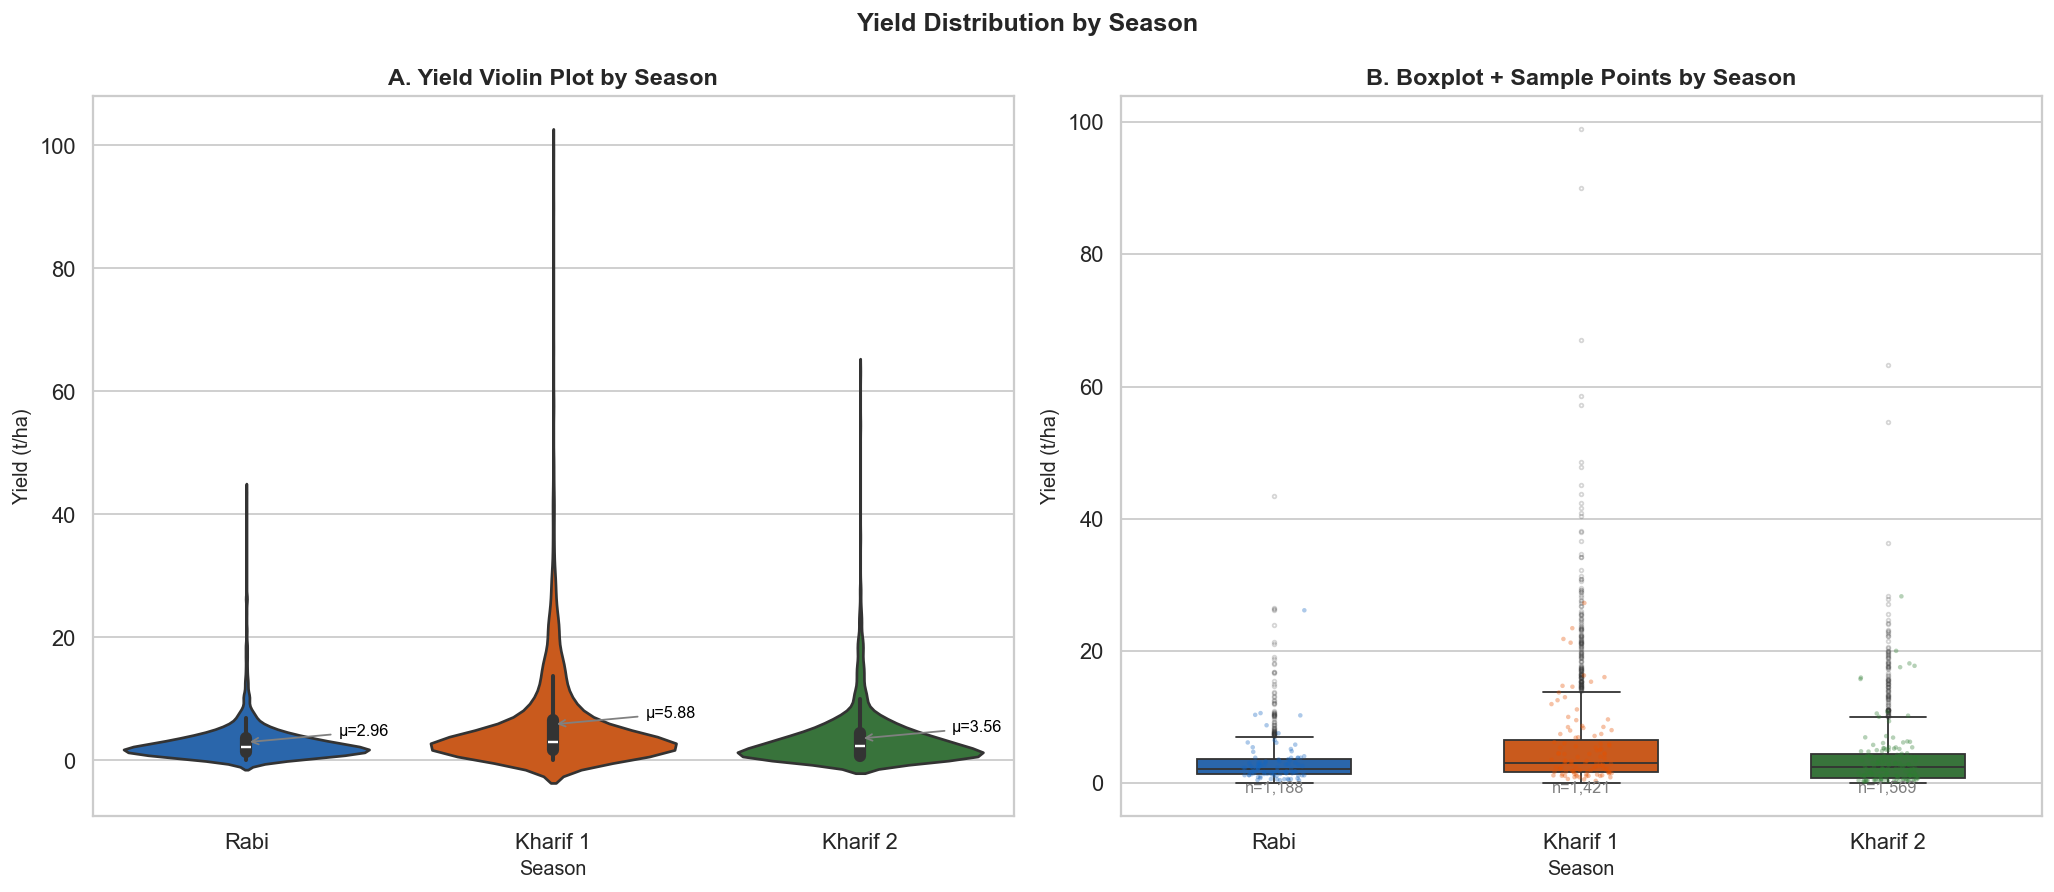


📌 Interpretation:
   The violin plot reveals that Kharif 2 (monsoon season) has the widest yield spread,
   suggesting high variability driven by rainfall fluctuations. Rabi (winter/dry season)
   shows a tighter distribution with fewer extreme outliers. Kharif 1 (pre-monsoon)
   has the most outliers in the upper tail.

🔗 Business Relevance:
   Season is a key variable for yield prediction. Models trained without season-awareness
   will underperform. Season-specific interventions (irrigation in Rabi, drainage in
   Kharif 2) can dramatically stabilise yields.



In [ ]:
season_order = ['Rabi', 'Kharif 1', 'Kharif 2']
season_palette = {'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'}

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Yield Distribution by Season', fontsize=14, fontweight='bold')

# ── Violin Plot ─────────────────────────────────────────
sns.violinplot(data=df, x='Season', y='Yield', order=season_order,
               palette=season_palette, inner='box',
               linewidth=1.5, ax=axes[0])
axes[0].set_title('A. Yield Violin Plot by Season', fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Yield (t/ha)')

for i, season in enumerate(season_order):
    m = df[df['Season']==season]['Yield'].mean()
    axes[0].annotate(f'μ={m:.2f}', xy=(i, m), xytext=(i+0.3, m+1),
                     fontsize=9, color='black',
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# ── Box Plot + Strip ────────────────────────────────────
sns.boxplot(data=df, x='Season', y='Yield', order=season_order,
            palette=season_palette, width=0.5,
            flierprops=dict(marker='o', markersize=2, alpha=0.2),
            ax=axes[1])
sns.stripplot(data=df.sample(frac=0.08, random_state=42), x='Season', y='Yield',
              order=season_order, palette=season_palette,
              alpha=0.35, jitter=True, size=2.5, ax=axes[1])
axes[1].set_title('B. Boxplot + Sample Points by Season', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Yield (t/ha)')

# Add record counts
for i, season in enumerate(season_order):
    n = len(df[df['Season']==season])
    axes[1].text(i, -1.5, f'n={n:,}', ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.savefig('viz3_yield_by_season.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   The violin plot reveals that Kharif 2 (monsoon season) has the widest yield spread,
   suggesting high variability driven by rainfall fluctuations. Rabi (winter/dry season)
   shows a tighter distribution with fewer extreme outliers. Kharif 1 (pre-monsoon)
   has the most outliers in the upper tail.

🔗 Business Relevance:
   Season is a key variable for yield prediction. Models trained without season-awareness
   will underperform. Season-specific interventions (irrigation in Rabi, drainage in
   Kharif 2) can dramatically stabilise yields.
""")

---

## 🔥 Visualization 4 — Heatmap: Correlation Matrix
### (Seaborn)

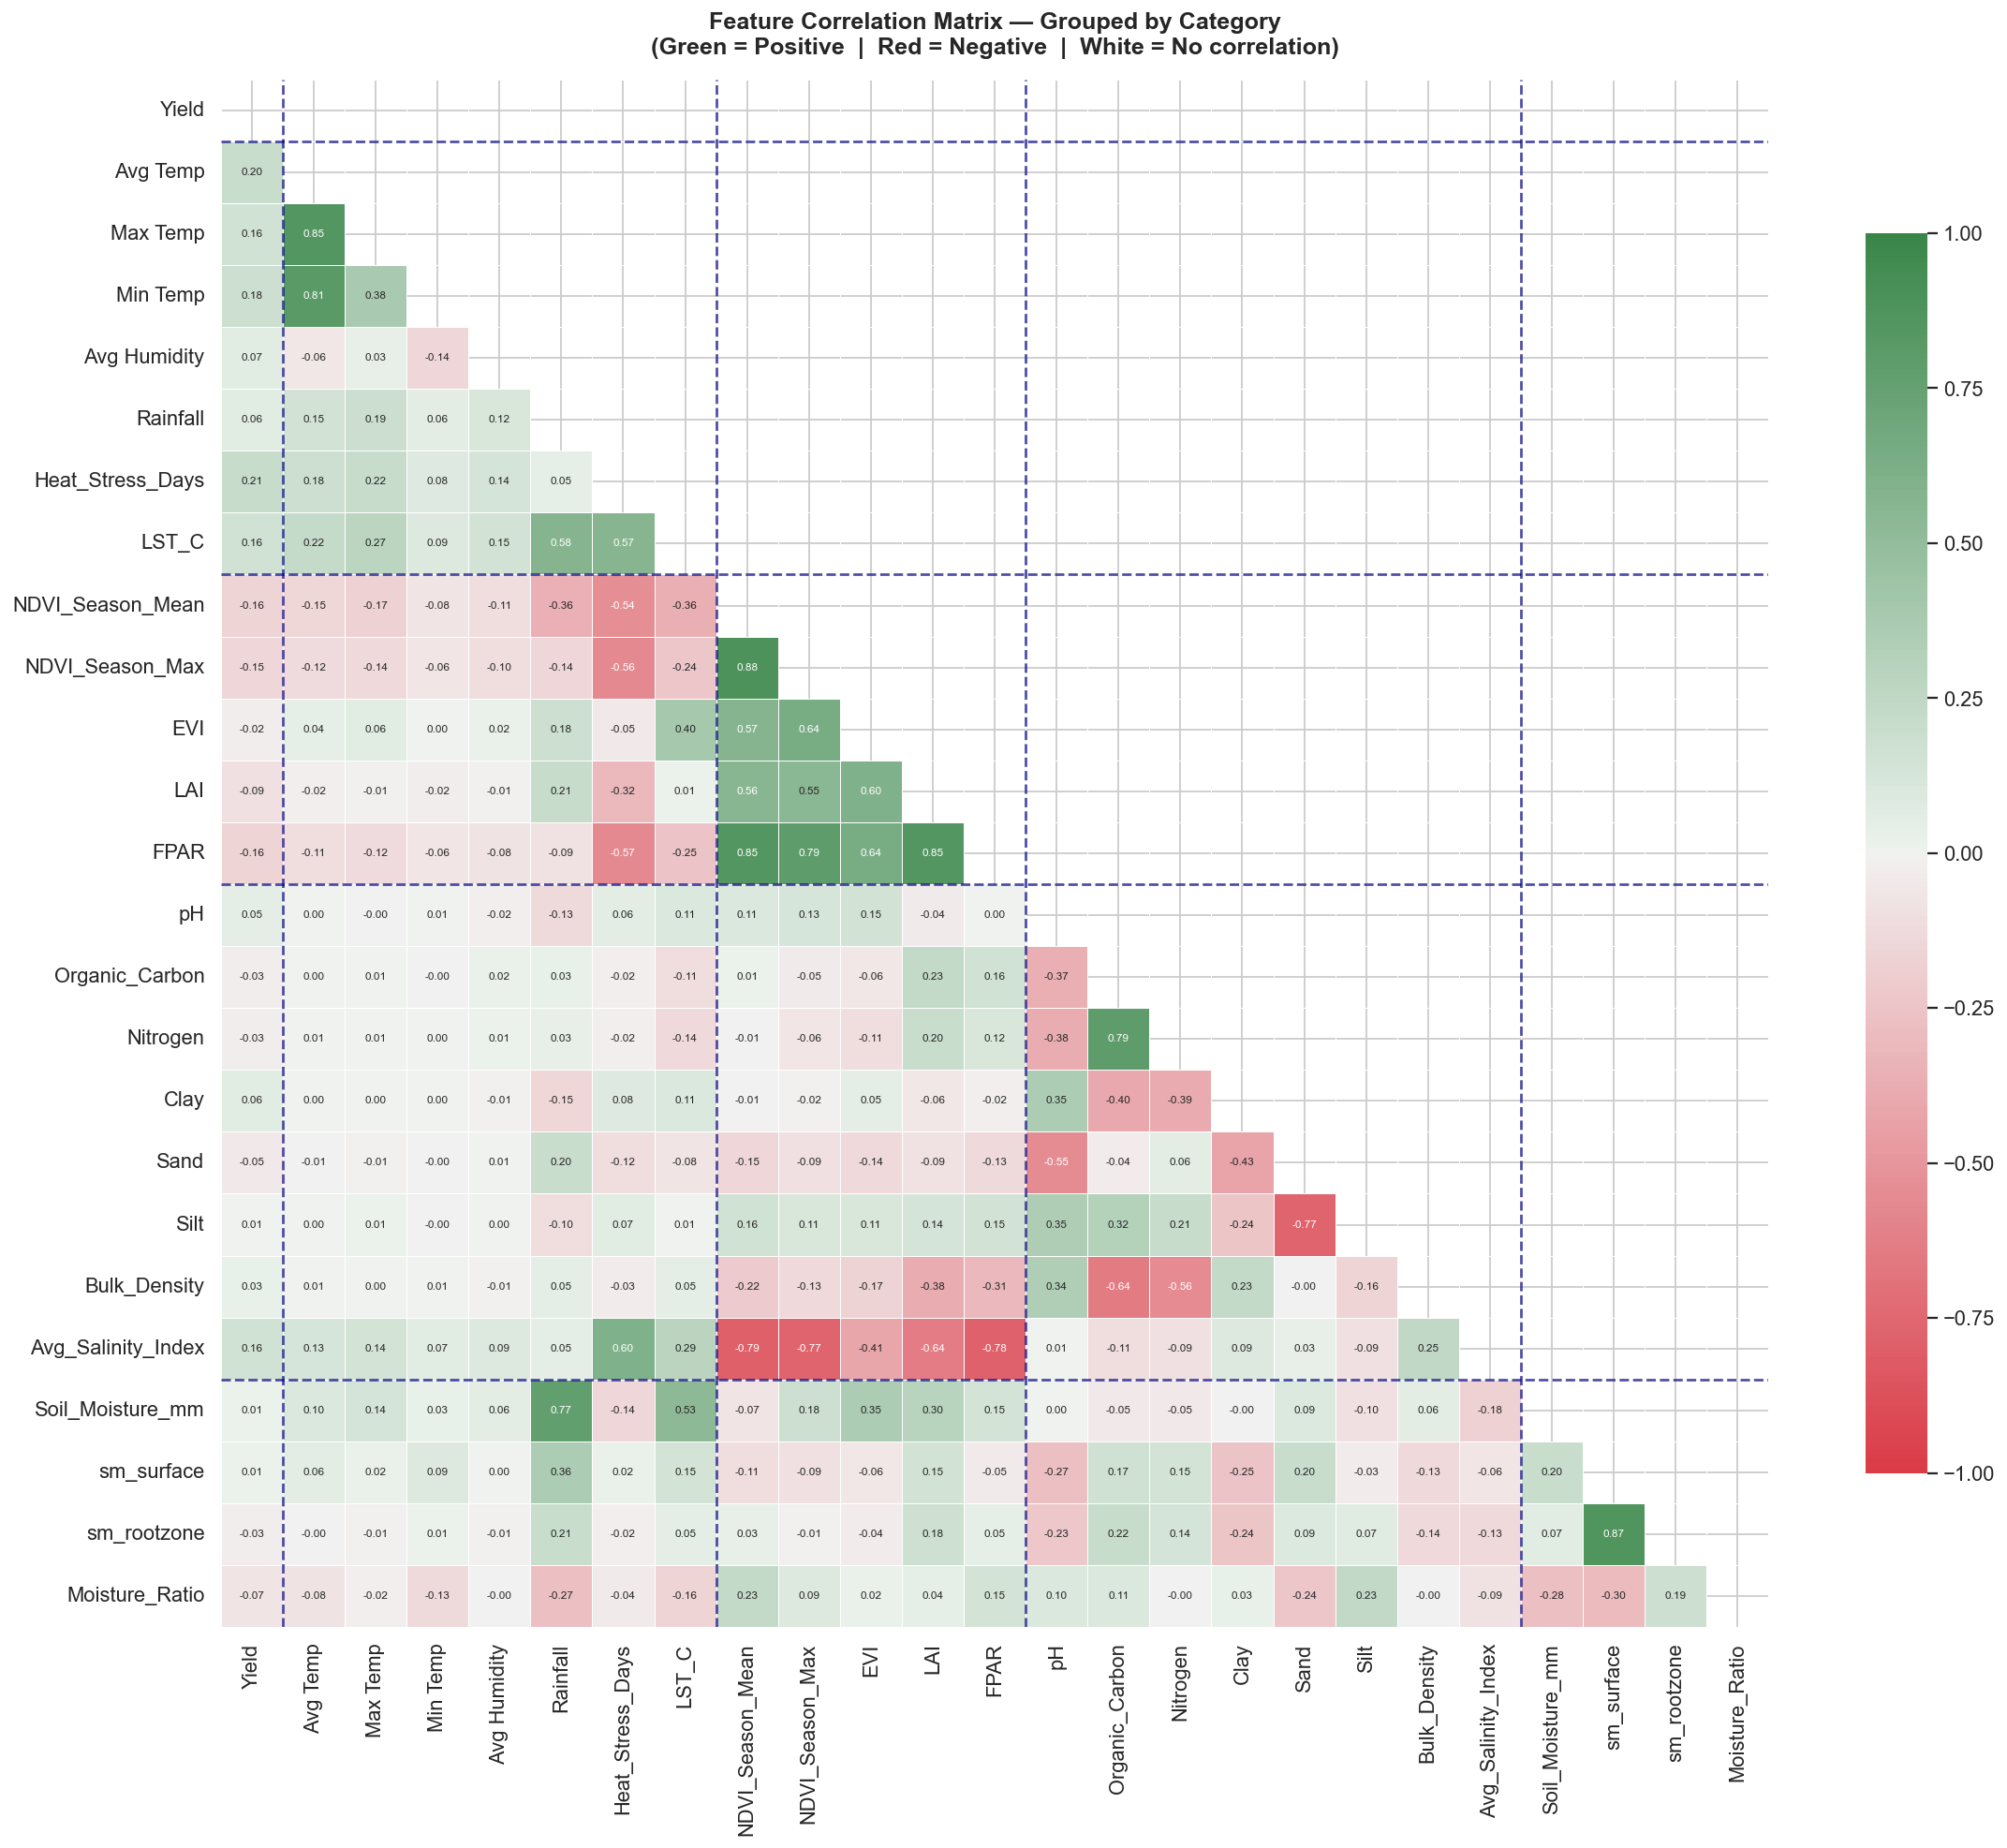


📌 Interpretation:
   The heatmap clearly reveals feature cluster correlations:
   • Vegetation indices (NDVI, EVI, LAI) are strongly inter-correlated (r > 0.85),
     indicating redundancy — one principal component may represent them all.
   • Soil moisture features (sm_surface, sm_rootzone) are highly correlated.
   • Temperature features (Avg Temp, LST_C, Heat_Stress_Days) cluster together.
   • Clay and Sand show strong negative correlation (r = -0.88) as expected.

🔗 Business Relevance:
   Highly correlated features cause multicollinearity in linear models. Selecting
   representative features per group (e.g., only NDVI_Mean for vegetation) reduces
   model complexity while retaining predictive power.



In [ ]:
feature_groups = {
    'Target'    : ['Yield'],
    'Climate'   : ['Avg Temp','Max Temp','Min Temp','Avg Humidity','Rainfall','Heat_Stress_Days','LST_C'],
    'Vegetation': ['NDVI_Season_Mean','NDVI_Season_Max','EVI','LAI','FPAR'],
    'Soil'      : ['pH','Organic_Carbon','Nitrogen','Clay','Sand','Silt','Bulk_Density','Avg_Salinity_Index'],
    'Moisture'  : ['Soil_Moisture_mm','sm_surface','sm_rootzone','Moisture_Ratio']
}
selected = [c for group in feature_groups.values() for c in group]
corr = df[selected].corr()

# Mask upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(18, 15))
cmap = sns.diverging_palette(10, 133, as_cmap=True)
sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 6.5},
            linewidths=0.4, vmin=-1, vmax=1, square=True,
            cbar_kws={'shrink': 0.8}, ax=ax)

ax.set_title('Feature Correlation Matrix — Grouped by Category\n'
             '(Green = Positive  |  Red = Negative  |  White = No correlation)',
             fontsize=14, fontweight='bold', pad=15)

# Draw group separation lines
cumulative = 0
ticks_pos, ticks_lbl = [], []
for group, cols in feature_groups.items():
    ticks_pos.append(cumulative + len(cols)/2)
    ticks_lbl.append(f'[{group}]\n({len(cols)} features)')
    cumulative += len(cols)
    if cumulative < len(selected):
        ax.axhline(cumulative, color='navy', lw=1.5, ls='--', alpha=0.7)
        ax.axvline(cumulative, color='navy', lw=1.5, ls='--', alpha=0.7)

plt.tight_layout()
plt.savefig('viz4_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   The heatmap clearly reveals feature cluster correlations:
   • Vegetation indices (NDVI, EVI, LAI) are strongly inter-correlated (r > 0.85),
     indicating redundancy — one principal component may represent them all.
   • Soil moisture features (sm_surface, sm_rootzone) are highly correlated.
   • Temperature features (Avg Temp, LST_C, Heat_Stress_Days) cluster together.
   • Clay and Sand show strong negative correlation (r = -0.88) as expected.

🔗 Business Relevance:
   Highly correlated features cause multicollinearity in linear models. Selecting
   representative features per group (e.g., only NDVI_Mean for vegetation) reduces
   model complexity while retaining predictive power.
""")

---

## 🔵 Visualization 5 — Scatter Plot: Rainfall vs Yield (by Season)
### (Matplotlib + Seaborn)

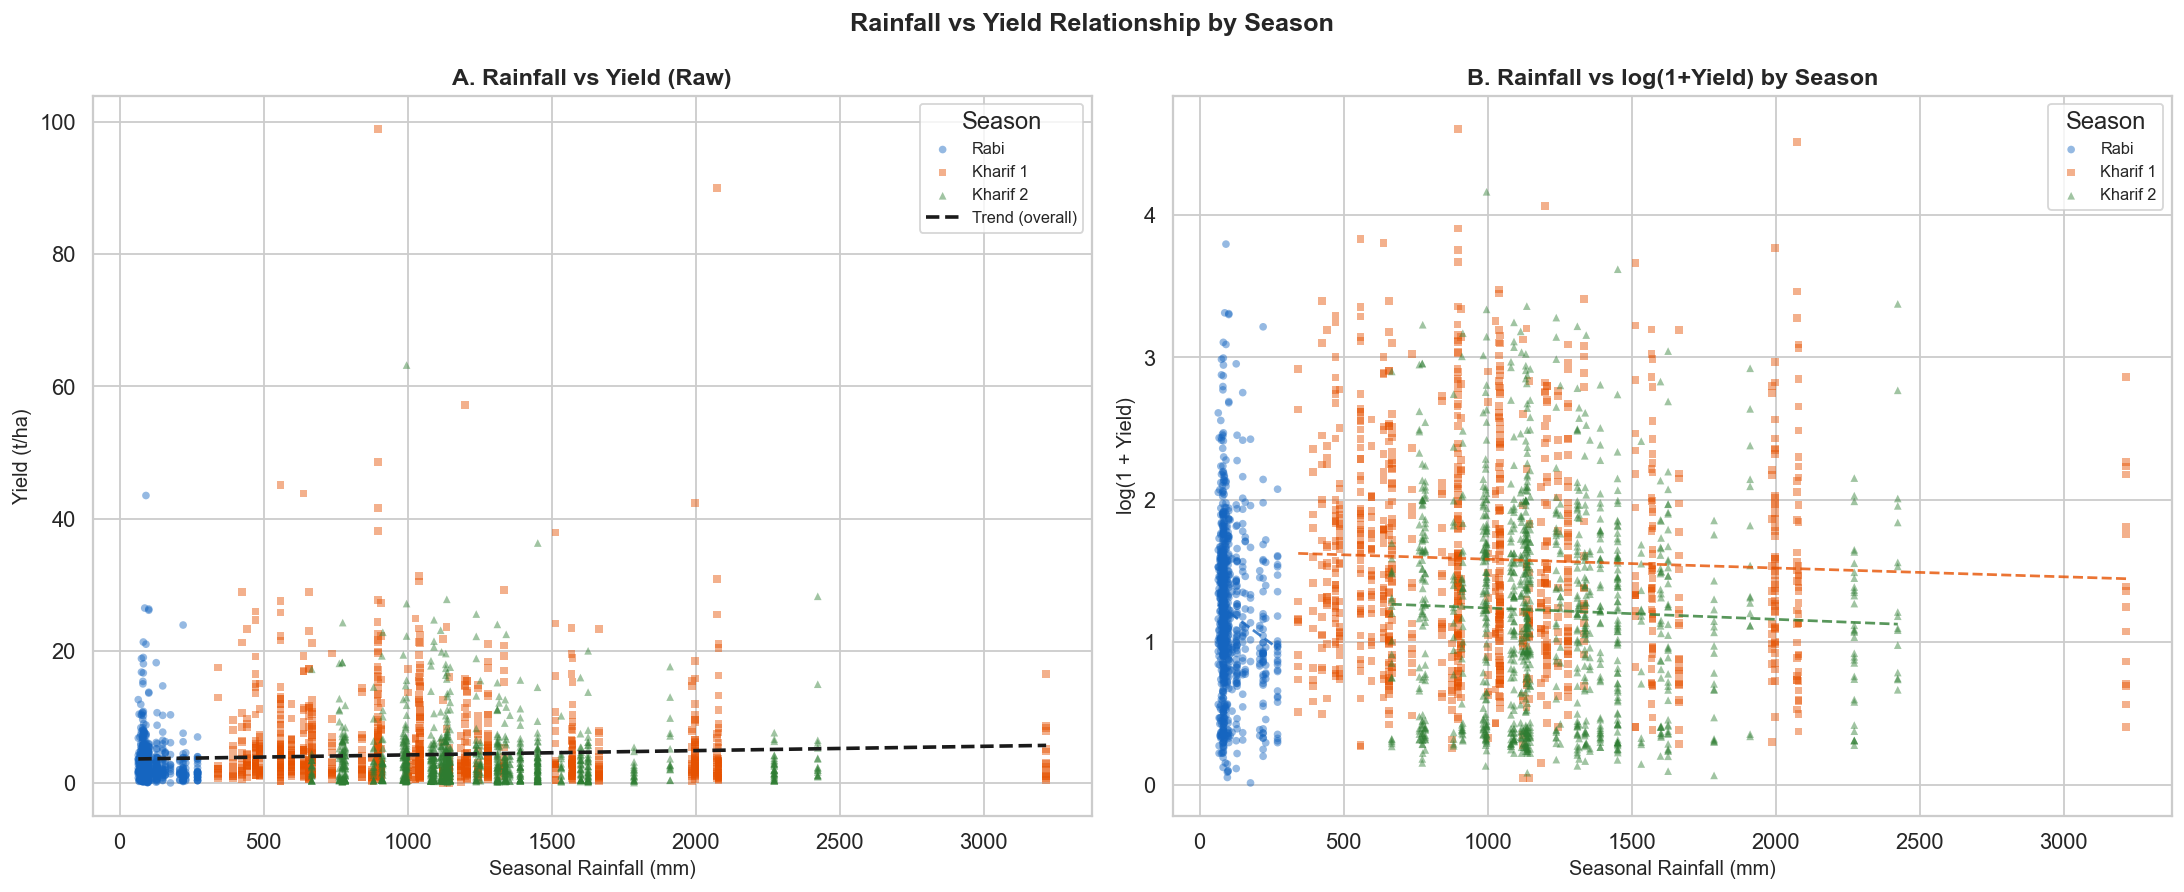


📌 Interpretation:
   Rainfall has a moderate positive relationship with yield, but the effect differs by season.
   Kharif 2 (monsoon) records the highest rainfall (800–2000mm) yet shows high variance —
   too much rainfall can cause waterlogging and reduce yields. Rabi season
   (low rainfall, 100–400mm) achieves competitive yields through irrigation.

🔗 Business Relevance:
   This non-linear relationship means that models must capture season × rainfall interactions.
   Irrigation infrastructure is critical for Rabi productivity; flood management
   is the priority for Kharif 2 districts.



In [ ]:
sample = df.sample(n=3000, random_state=42)
season_order = ['Rabi', 'Kharif 1', 'Kharif 2']
season_colors = {'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'}
season_markers = {'Rabi': 'o', 'Kharif 1': 's', 'Kharif 2': '^'}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Rainfall vs Yield Relationship by Season', fontsize=14, fontweight='bold')

for season in season_order:
    sub = sample[sample['Season'] == season]
    axes[0].scatter(sub['Rainfall'], sub['Yield'],
                    c=season_colors[season], marker=season_markers[season],
                    alpha=0.45, s=18, label=season, edgecolors='none')

# Overall trend line
z = np.polyfit(sample['Rainfall'], sample['Yield'], 1)
p = np.poly1d(z)
x_line = np.linspace(sample['Rainfall'].min(), sample['Rainfall'].max(), 200)
axes[0].plot(x_line, p(x_line), 'k--', lw=2, label='Trend (overall)')
axes[0].set_title('A. Rainfall vs Yield (Raw)', fontweight='bold')
axes[0].set_xlabel('Seasonal Rainfall (mm)')
axes[0].set_ylabel('Yield (t/ha)')
axes[0].legend(title='Season', fontsize=9)

# Log-scale version
for season in season_order:
    sub = sample[sample['Season'] == season]
    axes[1].scatter(sub['Rainfall'], np.log1p(sub['Yield']),
                    c=season_colors[season], marker=season_markers[season],
                    alpha=0.45, s=18, label=season, edgecolors='none')
    # Per-season regression
    z2 = np.polyfit(sub['Rainfall'], np.log1p(sub['Yield']), 1)
    p2 = np.poly1d(z2)
    xr = np.linspace(sub['Rainfall'].min(), sub['Rainfall'].max(), 200)
    axes[1].plot(xr, p2(xr), color=season_colors[season], lw=1.5, ls='--', alpha=0.8)

axes[1].set_title('B. Rainfall vs log(1+Yield) by Season', fontweight='bold')
axes[1].set_xlabel('Seasonal Rainfall (mm)')
axes[1].set_ylabel('log(1 + Yield)')
axes[1].legend(title='Season', fontsize=9)

plt.tight_layout()
plt.savefig('viz5_rainfall_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   Rainfall has a moderate positive relationship with yield, but the effect differs by season.
   Kharif 2 (monsoon) records the highest rainfall (800–2000mm) yet shows high variance —
   too much rainfall can cause waterlogging and reduce yields. Rabi season
   (low rainfall, 100–400mm) achieves competitive yields through irrigation.

🔗 Business Relevance:
   This non-linear relationship means that models must capture season × rainfall interactions.
   Irrigation infrastructure is critical for Rabi productivity; flood management
   is the priority for Kharif 2 districts.
""")

---

## 🟢 Visualization 6 — Scatter Plot: NDVI vs Yield (with EVI colour)
### (Matplotlib)

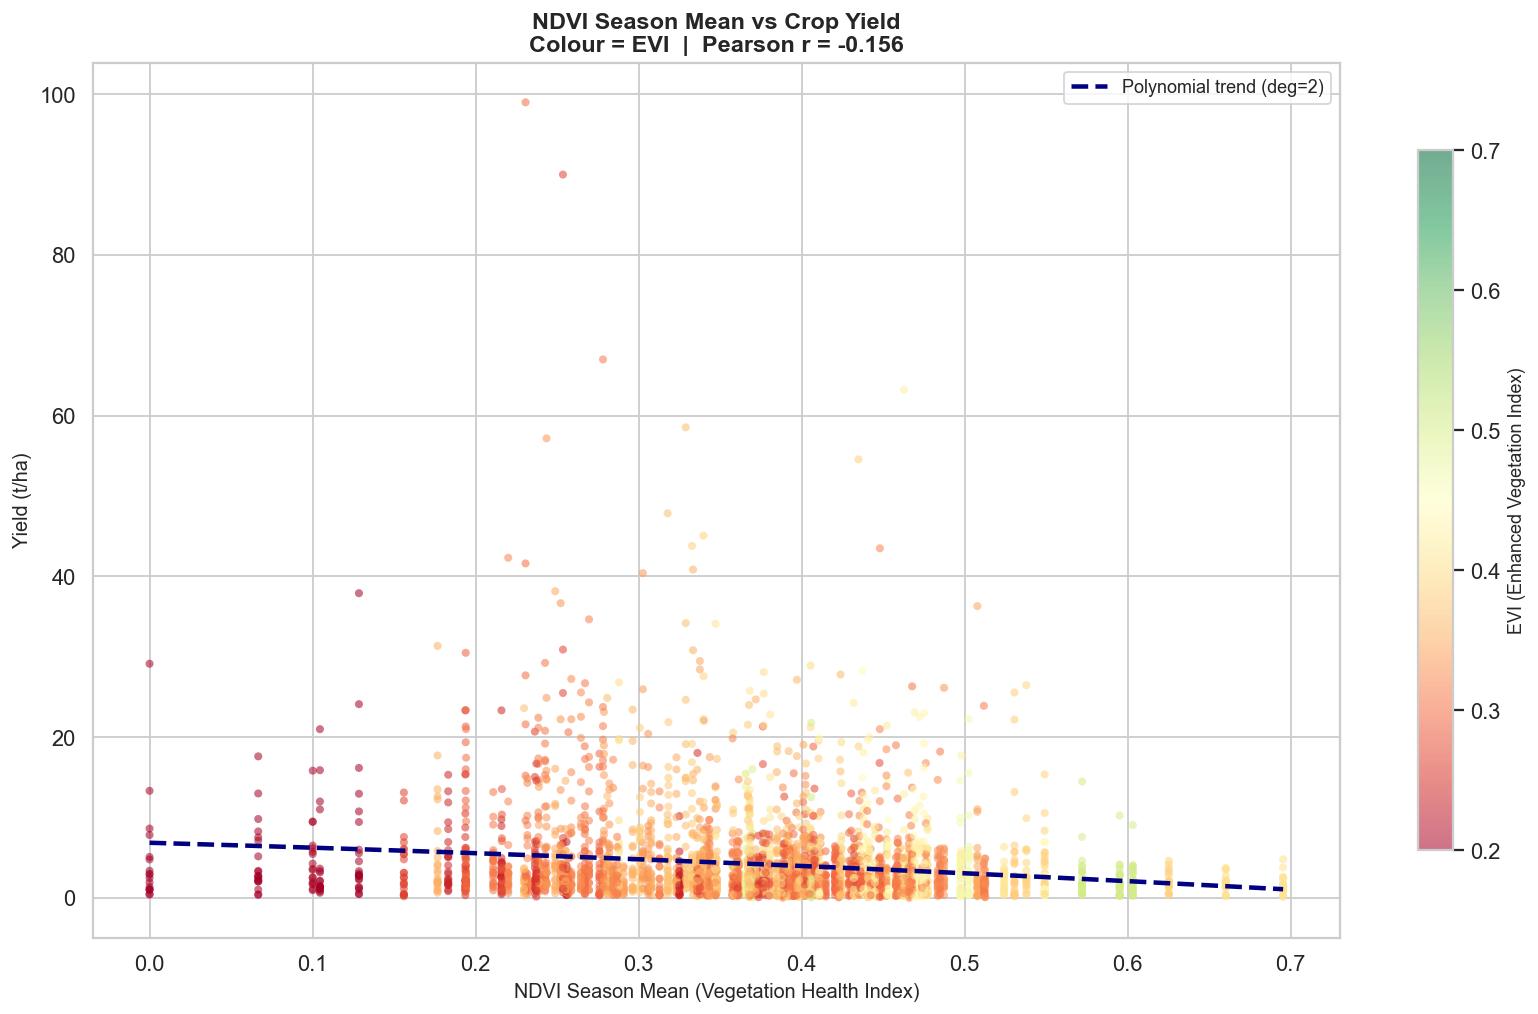


📌 Interpretation:
   NDVI (vegetation health measured by satellite) shows a moderate positive correlation
   with yield. Points with high EVI (dark green) tend to cluster at higher NDVI values,
   confirming that vegetation indices capture crop biomass accurately. The polynomial
   trend reveals diminishing returns — beyond NDVI ≈ 0.5, yield gains plateau.

🔗 Business Relevance:
   Remote sensing data (NDVI, EVI) can serve as an early-warning yield estimator before
   harvest. Satellite monitoring can replace costly field surveys at scale across all
   64 districts, enabling timely government interventions.



In [ ]:
sample2 = df.sample(n=4000, random_state=99)

fig, ax = plt.subplots(figsize=(13, 8))
sc = ax.scatter(sample2['NDVI_Season_Mean'], sample2['Yield'],
                c=sample2['EVI'], cmap='RdYlGn',
                alpha=0.55, s=20, edgecolors='none', vmin=0.2, vmax=0.7)

cbar = plt.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label('EVI (Enhanced Vegetation Index)', fontsize=10)

# Regression line
from numpy.polynomial.polynomial import polyfit as npfit
z = np.polyfit(sample2['NDVI_Season_Mean'], sample2['Yield'], 2)
p = np.poly1d(z)
xs = np.linspace(sample2['NDVI_Season_Mean'].min(), sample2['NDVI_Season_Mean'].max(), 300)
ax.plot(xs, p(xs), 'navy', lw=2.5, ls='--', label='Polynomial trend (deg=2)')

corr_val = df['NDVI_Season_Mean'].corr(df['Yield'])
ax.set_title(f'NDVI Season Mean vs Crop Yield\n'
             f'Colour = EVI  |  Pearson r = {corr_val:.3f}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('NDVI Season Mean (Vegetation Health Index)', fontsize=11)
ax.set_ylabel('Yield (t/ha)', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz6_ndvi_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   NDVI (vegetation health measured by satellite) shows a moderate positive correlation
   with yield. Points with high EVI (dark green) tend to cluster at higher NDVI values,
   confirming that vegetation indices capture crop biomass accurately. The polynomial
   trend reveals diminishing returns — beyond NDVI ≈ 0.5, yield gains plateau.

🔗 Business Relevance:
   Remote sensing data (NDVI, EVI) can serve as an early-warning yield estimator before
   harvest. Satellite monitoring can replace costly field surveys at scale across all
   64 districts, enabling timely government interventions.
""")

---

## 🟠 Visualization 7 — Scatter Plot: Temperature vs Yield (Heat Stress)
### (Matplotlib)

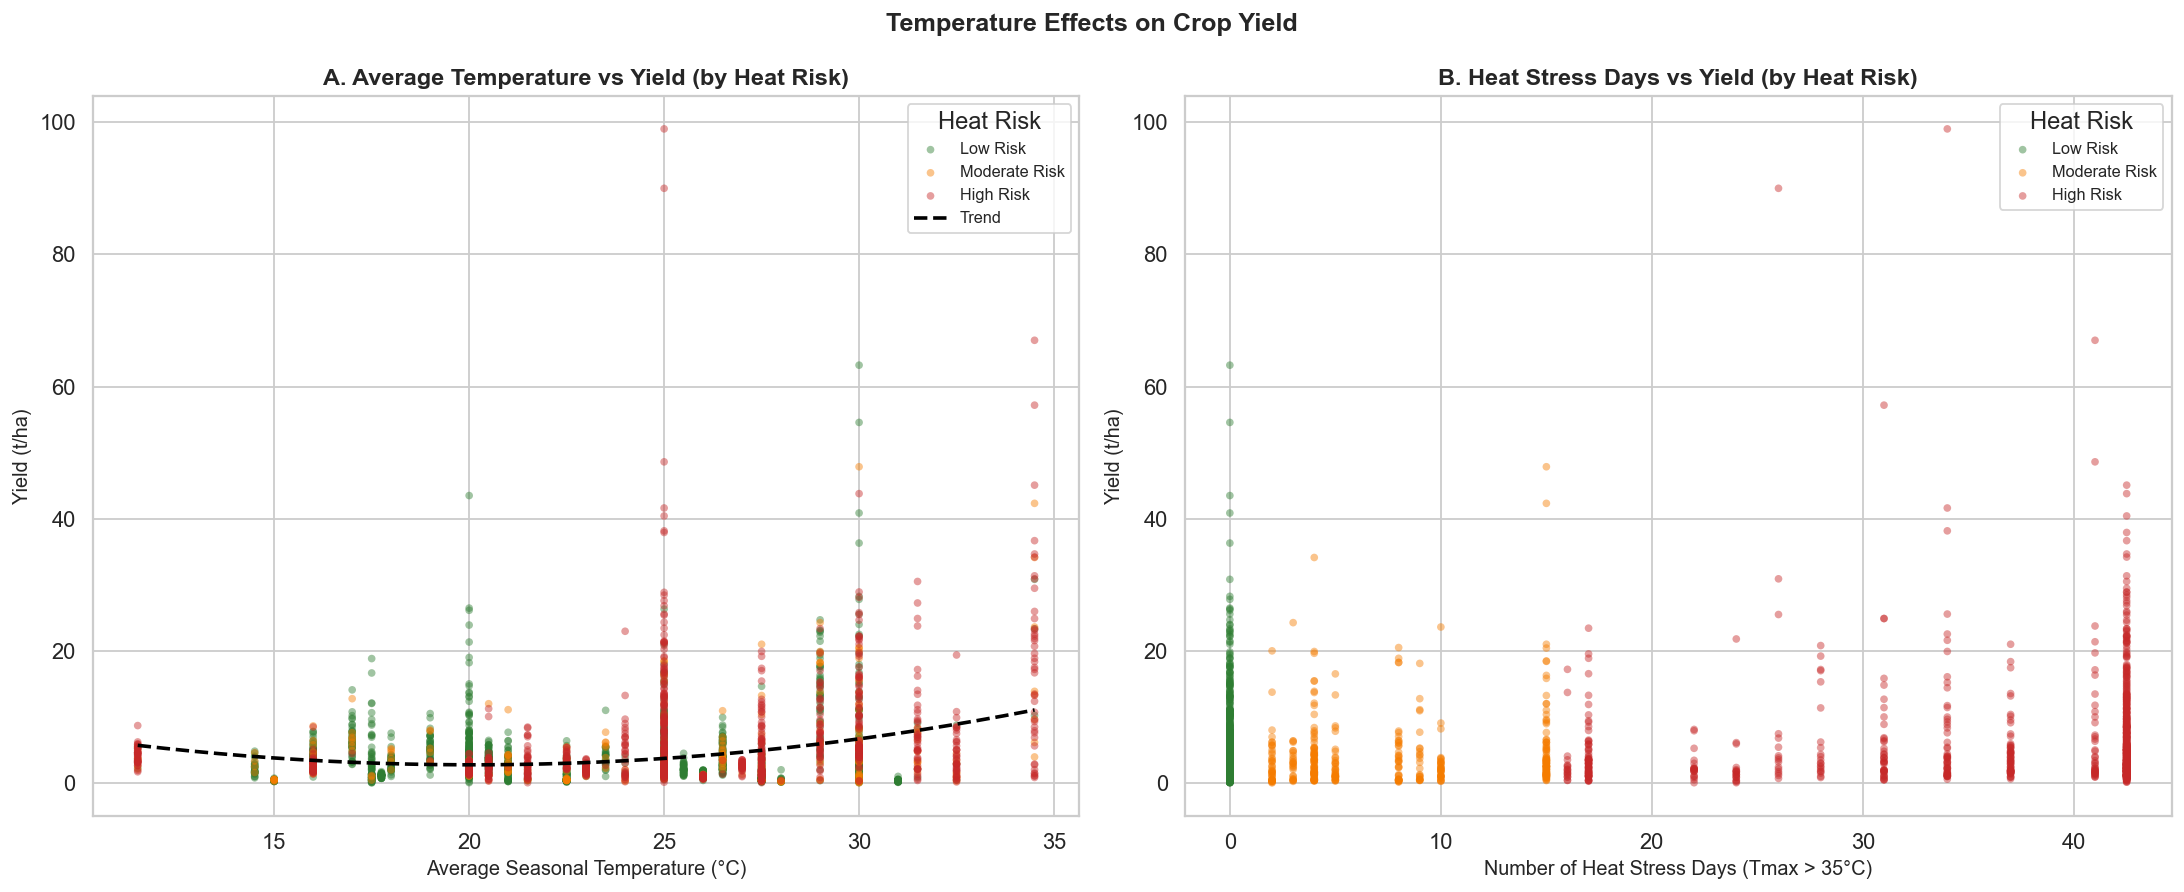


📌 Interpretation:
   Panel A shows an inverted-U relationship: yields peak at moderate temperatures
   (~25–30°C) and decline at extremes. High-risk heat events (red) concentrate in
   the high-temperature zone with reduced yields. Panel B confirms that more
   heat-stress days correlate with lower and more variable yields.

🔗 Business Relevance:
   Climate change projections suggest rising temperatures will increase heat-stress days.
   Breeding heat-tolerant varieties and adjusting sowing calendars are critical
   adaptation strategies for Bangladesh's food security.



In [ ]:
sample3 = df.sample(n=3500, random_state=7)
heat_colors = {'Low Risk': '#2E7D32', 'Moderate Risk': '#F57C00', 'High Risk': '#C62828'}

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
fig.suptitle('Temperature Effects on Crop Yield', fontsize=14, fontweight='bold')

# ── Panel A: Avg Temp vs Yield coloured by Heat Risk ────
for risk, color in heat_colors.items():
    sub = sample3[sample3['Extreme_Heat_Risk'] == risk]
    axes[0].scatter(sub['Avg Temp'], sub['Yield'],
                    c=color, alpha=0.45, s=18, label=risk, edgecolors='none')

z3 = np.polyfit(sample3['Avg Temp'], sample3['Yield'], 2)
p3 = np.poly1d(z3)
xt = np.linspace(sample3['Avg Temp'].min(), sample3['Avg Temp'].max(), 200)
axes[0].plot(xt, p3(xt), 'black', lw=2, ls='--', label='Trend')
axes[0].set_title('A. Average Temperature vs Yield (by Heat Risk)', fontweight='bold')
axes[0].set_xlabel('Average Seasonal Temperature (°C)')
axes[0].set_ylabel('Yield (t/ha)')
axes[0].legend(title='Heat Risk', fontsize=9)

# ── Panel B: Heat Stress Days vs Yield ──────────────────
for risk, color in heat_colors.items():
    sub = sample3[sample3['Extreme_Heat_Risk'] == risk]
    axes[1].scatter(sub['Heat_Stress_Days'], sub['Yield'],
                    c=color, alpha=0.45, s=18, label=risk, edgecolors='none')

axes[1].set_title('B. Heat Stress Days vs Yield (by Heat Risk)', fontweight='bold')
axes[1].set_xlabel('Number of Heat Stress Days (Tmax > 35°C)')
axes[1].set_ylabel('Yield (t/ha)')
axes[1].legend(title='Heat Risk', fontsize=9)

plt.tight_layout()
plt.savefig('viz7_temperature_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   Panel A shows an inverted-U relationship: yields peak at moderate temperatures
   (~25–30°C) and decline at extremes. High-risk heat events (red) concentrate in
   the high-temperature zone with reduced yields. Panel B confirms that more
   heat-stress days correlate with lower and more variable yields.

🔗 Business Relevance:
   Climate change projections suggest rising temperatures will increase heat-stress days.
   Breeding heat-tolerant varieties and adjusting sowing calendars are critical
   adaptation strategies for Bangladesh's food security.
""")

---

## 🌱 Visualization 8 — Bar Chart: Soil pH Suitability vs Yield by Soil Texture
### (Seaborn)

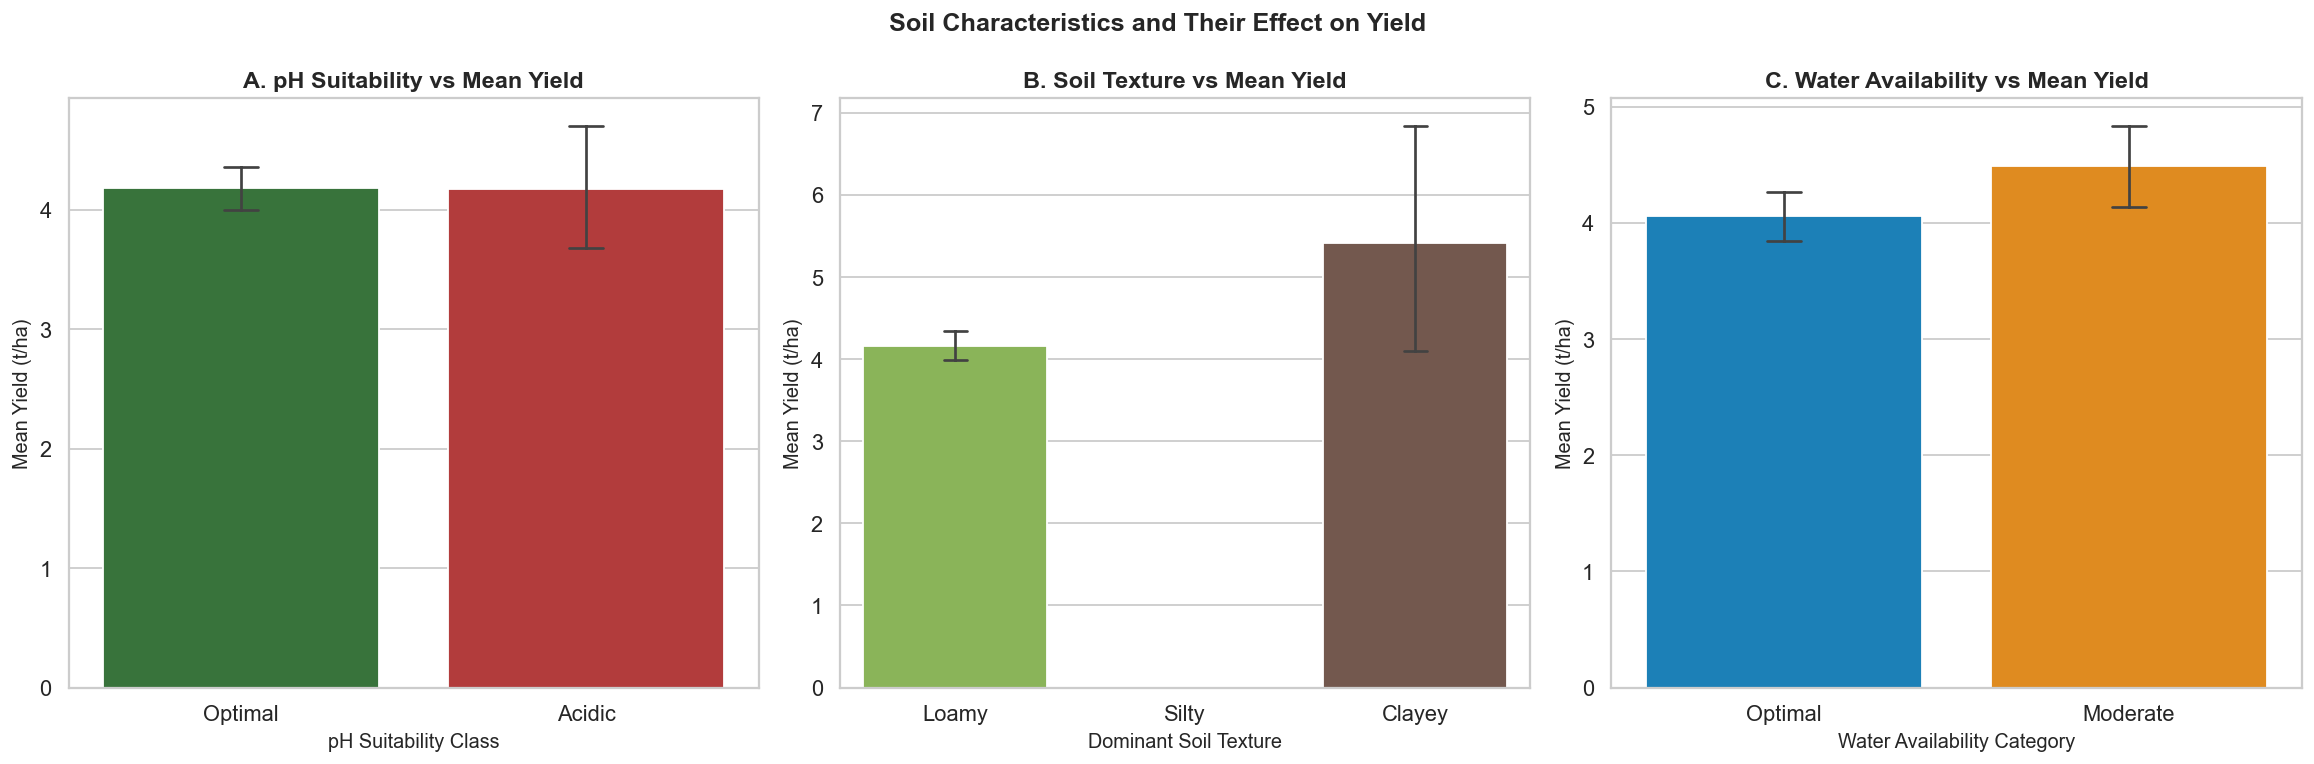


📌 Interpretation:
   Optimal soil pH produces significantly higher yields than acidic soils.
   Loamy soils outperform clay-heavy soils in average yield due to better
   drainage and aeration. Optimal water availability consistently produces
   higher yields than moderate conditions.

🔗 Business Relevance:
   Soil management practices (liming for pH correction, drainage for clay soils)
   have direct, measurable impacts on yield. These categorical soil features
   are cost-effective additions to yield prediction models.



In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Soil Characteristics and Their Effect on Yield',
             fontsize=14, fontweight='bold')

# ── Panel A: pH Suitability ─────────────────────────────
ph_stats = df.groupby('pH_Suitability')['Yield'].mean().reset_index()
sns.barplot(data=df, x='pH_Suitability', y='Yield',
            palette={'Optimal': '#2E7D32', 'Acidic': '#C62828'},
            order=['Optimal','Acidic'],
            capsize=0.1, errwidth=1.5, ax=axes[0])
axes[0].set_title('A. pH Suitability vs Mean Yield', fontweight='bold')
axes[0].set_xlabel('pH Suitability Class')
axes[0].set_ylabel('Mean Yield (t/ha)')

# ── Panel B: Soil Texture ────────────────────────────────
sns.barplot(data=df, x='Dominant_Soil_Texture', y='Yield',
            palette={'Loamy': '#8BC34A', 'Silty': '#03A9F4', 'Clayey': '#795548'},
            order=['Loamy','Silty','Clayey'],
            capsize=0.1, errwidth=1.5, ax=axes[1])
axes[1].set_title('B. Soil Texture vs Mean Yield', fontweight='bold')
axes[1].set_xlabel('Dominant Soil Texture')
axes[1].set_ylabel('Mean Yield (t/ha)')

# ── Panel C: Water Availability ─────────────────────────
sns.barplot(data=df, x='Water_Availability_Cat', y='Yield',
            palette={'Optimal': '#0288D1', 'Moderate': '#FF8F00'},
            order=['Optimal','Moderate'],
            capsize=0.1, errwidth=1.5, ax=axes[2])
axes[2].set_title('C. Water Availability vs Mean Yield', fontweight='bold')
axes[2].set_xlabel('Water Availability Category')
axes[2].set_ylabel('Mean Yield (t/ha)')

plt.tight_layout()
plt.savefig('viz8_soil_vs_yield.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   Optimal soil pH produces significantly higher yields than acidic soils.
   Loamy soils outperform clay-heavy soils in average yield due to better
   drainage and aeration. Optimal water availability consistently produces
   higher yields than moderate conditions.

🔗 Business Relevance:
   Soil management practices (liming for pH correction, drainage for clay soils)
   have direct, measurable impacts on yield. These categorical soil features
   are cost-effective additions to yield prediction models.
""")

---

## 📉 Visualization 9 — Line Chart: Organic Carbon vs Mean Yield (by Soil Texture)
### (Matplotlib)

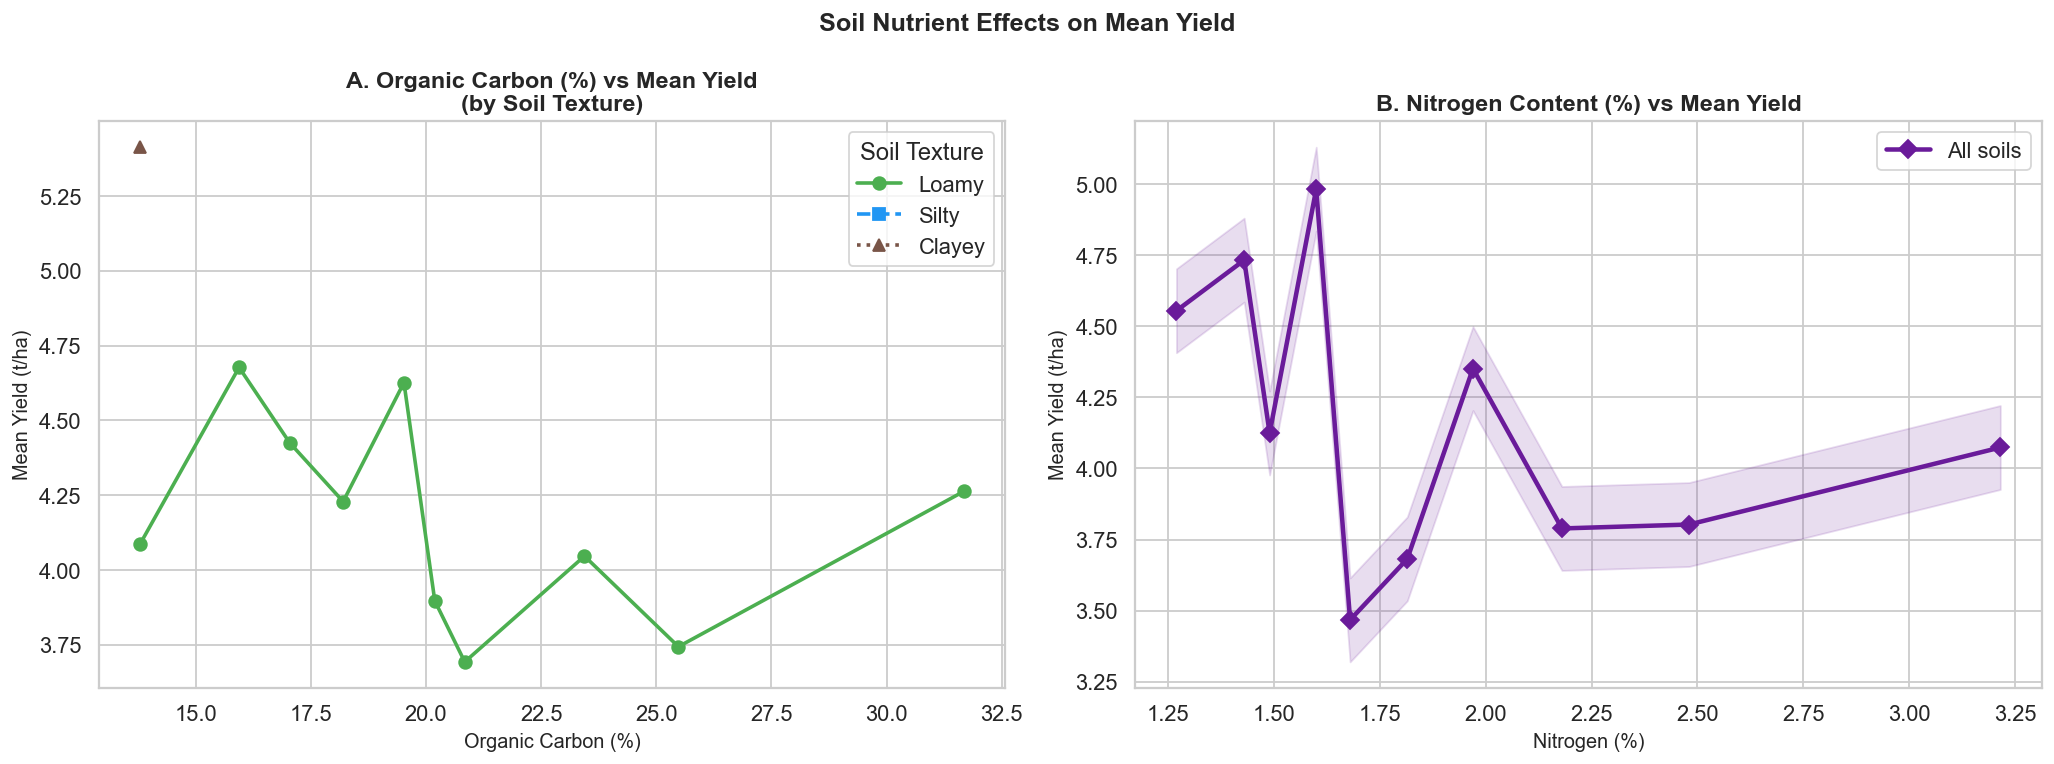


📌 Interpretation:
   Both organic carbon and nitrogen show a positive, approximately linear relationship
   with yield. Loamy soils benefit the most from high organic carbon, while clayey
   soils show a flatter response. This suggests that fertilisation strategies
   should be tailored to soil texture type.

🔗 Business Relevance:
   Precision fertilisation guided by soil maps can increase yields efficiently.
   Nitrogen content is one of the most actionable variables — farmers can directly
   improve it through composting and fertiliser application.



In [ ]:
# Bin Organic Carbon into quantile deciles
df['OC_bin'] = pd.qcut(df['Organic_Carbon'], q=10, labels=False, duplicates='drop')
df['N_bin']  = pd.qcut(df['Nitrogen'], q=10, labels=False, duplicates='drop')

oc_line = df.groupby(['OC_bin','Dominant_Soil_Texture'])['Yield'].mean().reset_index()
oc_val  = df.groupby('OC_bin')['Organic_Carbon'].median().reset_index()
oc_line = oc_line.merge(oc_val, on='OC_bin')

n_line = df.groupby(['N_bin'])['Yield'].mean().reset_index()
n_val  = df.groupby('N_bin')['Nitrogen'].median().reset_index()
n_line = n_line.merge(n_val, on='N_bin')

texture_style = {
    'Loamy': {'color': '#4CAF50', 'marker': 'o', 'ls': '-'},
    'Silty': {'color': '#2196F3', 'marker': 's', 'ls': '--'},
    'Clayey':{'color': '#795548', 'marker': '^', 'ls': ':'},
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Soil Nutrient Effects on Mean Yield', fontsize=14, fontweight='bold')

# ── Panel A: OC by soil texture ──────────────────────────
for texture, style in texture_style.items():
    sub = oc_line[oc_line['Dominant_Soil_Texture'] == texture]
    axes[0].plot(sub['Organic_Carbon'], sub['Yield'],
                 color=style['color'], marker=style['marker'],
                 ls=style['ls'], lw=2, ms=7, label=texture)

axes[0].set_title('A. Organic Carbon (%) vs Mean Yield\n(by Soil Texture)', fontweight='bold')
axes[0].set_xlabel('Organic Carbon (%)')
axes[0].set_ylabel('Mean Yield (t/ha)')
axes[0].legend(title='Soil Texture')

# ── Panel B: Nitrogen ────────────────────────────────────
axes[1].plot(n_line['Nitrogen'], n_line['Yield'],
             color='#6A1B9A', marker='D', lw=2.5, ms=7, label='All soils')
axes[1].fill_between(n_line['Nitrogen'],
                     n_line['Yield'] - n_line['Yield'].std()*0.3,
                     n_line['Yield'] + n_line['Yield'].std()*0.3,
                     alpha=0.15, color='#6A1B9A')
axes[1].set_title('B. Nitrogen Content (%) vs Mean Yield', fontweight='bold')
axes[1].set_xlabel('Nitrogen (%)')
axes[1].set_ylabel('Mean Yield (t/ha)')
axes[1].legend()

plt.tight_layout()
plt.savefig('viz9_soil_nutrient_line.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   Both organic carbon and nitrogen show a positive, approximately linear relationship
   with yield. Loamy soils benefit the most from high organic carbon, while clayey
   soils show a flatter response. This suggests that fertilisation strategies
   should be tailored to soil texture type.

🔗 Business Relevance:
   Precision fertilisation guided by soil maps can increase yields efficiently.
   Nitrogen content is one of the most actionable variables — farmers can directly
   improve it through composting and fertiliser application.
""")

---

## 🗺️ Visualization 10 — Plotly Interactive: Yield by District (Bar Chart)
### (Plotly)

In [ ]:
dist_stats = (df.groupby('District')['Yield']
                .agg(Mean_Yield='mean', Std='std', Count='count')
                .round(3).reset_index()
                .sort_values('Mean_Yield', ascending=False))
dist_stats['SE'] = (dist_stats['Std'] / np.sqrt(dist_stats['Count'])).round(3)

fig = go.Figure()
fig.add_trace(go.Bar(
    x=dist_stats['District'],
    y=dist_stats['Mean_Yield'],
    error_y=dict(type='data', array=dist_stats['SE'], visible=True),
    marker=dict(
        color=dist_stats['Mean_Yield'],
        colorscale='YlGn',
        showscale=True,
        colorbar=dict(title='Mean Yield (t/ha)')
    ),
    text=dist_stats['Mean_Yield'].round(2),
    textposition='outside',
    hovertemplate='<b>%{x}</b><br>Mean Yield: %{y:.2f} t/ha<br>Records: %{customdata}<extra></extra>',
    customdata=dist_stats['Count']
))

fig.add_hline(y=df['Yield'].mean(), line_dash='dash', line_color='red',
              annotation_text=f'Overall Mean = {df["Yield"].mean():.2f}',
              annotation_position='bottom right')

fig.update_layout(
    title=dict(text='🗺️ Average Crop Yield by District — All 64 Bangladesh Districts<br>'
                    '<sup>Sorted by Mean Yield  |  Error bars = Standard Error</sup>',
               font=dict(size=16)),
    xaxis=dict(title='District', tickangle=-55, tickfont=dict(size=10)),
    yaxis=dict(title='Mean Yield (t/ha)'),
    height=600, template='plotly_white',
    hoverlabel=dict(bgcolor='white', bordercolor='green')
)
fig.write_html('viz10_district_yield_interactive.html')
fig.show()

print("""
📌 Interpretation:
   This interactive chart allows exploration of all 64 district yields.
   Districts in northern Bangladesh (Rangpur division) tend to show higher
   average yields, benefiting from fertile alluvial soils. Coastal districts
   (Barguna, Patuakhali) show lower yields due to salinity stress.
   Hover over each bar to see the exact values and sample sizes.

🔗 Business Relevance:
   Geographic yield mapping enables targeted agricultural investment.
   High-yield districts validate current best practices; low-yield districts
   need prioritised extension services and input support.
""")


📌 Interpretation:
   This interactive chart allows exploration of all 64 district yields.
   Districts in northern Bangladesh (Rangpur division) tend to show higher
   average yields, benefiting from fertile alluvial soils. Coastal districts
   (Barguna, Patuakhali) show lower yields due to salinity stress.
   Hover over each bar to see the exact values and sample sizes.

🔗 Business Relevance:
   Geographic yield mapping enables targeted agricultural investment.
   High-yield districts validate current best practices; low-yield districts
   need prioritised extension services and input support.



---

## 🫧 Visualization 11 — Plotly Interactive Bubble Chart: Area × Yield × Production
### (Plotly)

In [ ]:
crop_bubble = (df.groupby(['Crop Name','Season'])
                 .agg(Mean_Yield=('Yield','mean'),
                      Mean_Area=('Area','mean'),
                      Total_Production=('Production','sum'),
                      Count=('Yield','count'))
                 .reset_index().round(2))

fig2 = px.scatter(
    crop_bubble,
    x='Mean_Area', y='Mean_Yield',
    size='Total_Production', color='Season',
    hover_name='Crop Name',
    size_max=60,
    color_discrete_map={'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'},
    labels={'Mean_Area': 'Mean Harvested Area (ha)',
            'Mean_Yield': 'Mean Yield (t/ha)',
            'Total_Production': 'Total Production (tonnes)'},
    title='🫧 Crop Area × Yield × Total Production Bubble Chart<br>'
          '<sup>Bubble size = Total Production  |  Colour = Season</sup>',
    log_x=True
)
fig2.update_layout(height=600, template='plotly_white',
                   legend=dict(title='Season', font=dict(size=11)),
                   title_font_size=15)
fig2.write_html('viz11_bubble_area_yield.html')
fig2.show()

print("""
📌 Interpretation:
   The bubble chart reveals that some crops have small harvested area but very high
   yield (top-left), while others occupy large areas with modest yields (bottom-right).
   Bubble size (total production) highlights strategic crops — Boro rice has the
   largest bubble, confirming it is Bangladesh's dominant staple food crop.

🔗 Business Relevance:
   Policymakers should distinguish between high-yield crops (intensive farming)
   and high-production crops (staple food security). This chart guides resource
   allocation between food security crops vs high-value export crops.
""")


📌 Interpretation:
   The bubble chart reveals that some crops have small harvested area but very high
   yield (top-left), while others occupy large areas with modest yields (bottom-right).
   Bubble size (total production) highlights strategic crops — Boro rice has the
   largest bubble, confirming it is Bangladesh's dominant staple food crop.

🔗 Business Relevance:
   Policymakers should distinguish between high-yield crops (intensive farming)
   and high-production crops (staple food security). This chart guides resource
   allocation between food security crops vs high-value export crops.



---

## 🎯 Visualization 12 — Plotly Interactive: Pair Plot of Key Features
### (Plotly)

In [ ]:
pair_vars = ['Yield','Avg Temp','Rainfall','NDVI_Season_Mean','Organic_Carbon','Soil_Moisture_mm']
pair_sample = df.sample(n=2000, random_state=42)[pair_vars + ['Season']]

fig3 = px.scatter_matrix(
    pair_sample,
    dimensions=pair_vars,
    color='Season',
    color_discrete_map={'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'},
    opacity=0.4,
    title='🎯 Interactive Pair Plot — Key Features by Season<br>'
          '<sup>Click legend to isolate seasons  |  Diagonal = distribution</sup>'
)
fig3.update_traces(marker=dict(size=3), diagonal_visible=True)
fig3.update_layout(height=900, template='plotly_white', title_font_size=14)
fig3.write_html('viz12_pairplot.html')
fig3.show()

print("""
📌 Interpretation:
   The scatter matrix enables simultaneous examination of all pairwise feature
   relationships. Clear patterns emerge:
   • NDVI × Yield: moderate positive correlation for all seasons
   • Rainfall × Avg Temp: season separation is clear (Kharif = hot & wet; Rabi = cool & dry)
   • Organic Carbon × Soil Moisture: positively linked, both promote yield

🔗 Business Relevance:
   Pair plots guide feature selection for machine learning models. Strongly correlated
   feature pairs (like NDVI and EVI) should be addressed via dimensionality reduction
   to avoid model overfitting.
""")


📌 Interpretation:
   The scatter matrix enables simultaneous examination of all pairwise feature
   relationships. Clear patterns emerge:
   • NDVI × Yield: moderate positive correlation for all seasons
   • Rainfall × Avg Temp: season separation is clear (Kharif = hot & wet; Rabi = cool & dry)
   • Organic Carbon × Soil Moisture: positively linked, both promote yield

🔗 Business Relevance:
   Pair plots guide feature selection for machine learning models. Strongly correlated
   feature pairs (like NDVI and EVI) should be addressed via dimensionality reduction
   to avoid model overfitting.



---

## 🌡️ Visualization 13 — Grouped Bar: Crop Count & Avg Yield by Season
### (Matplotlib)

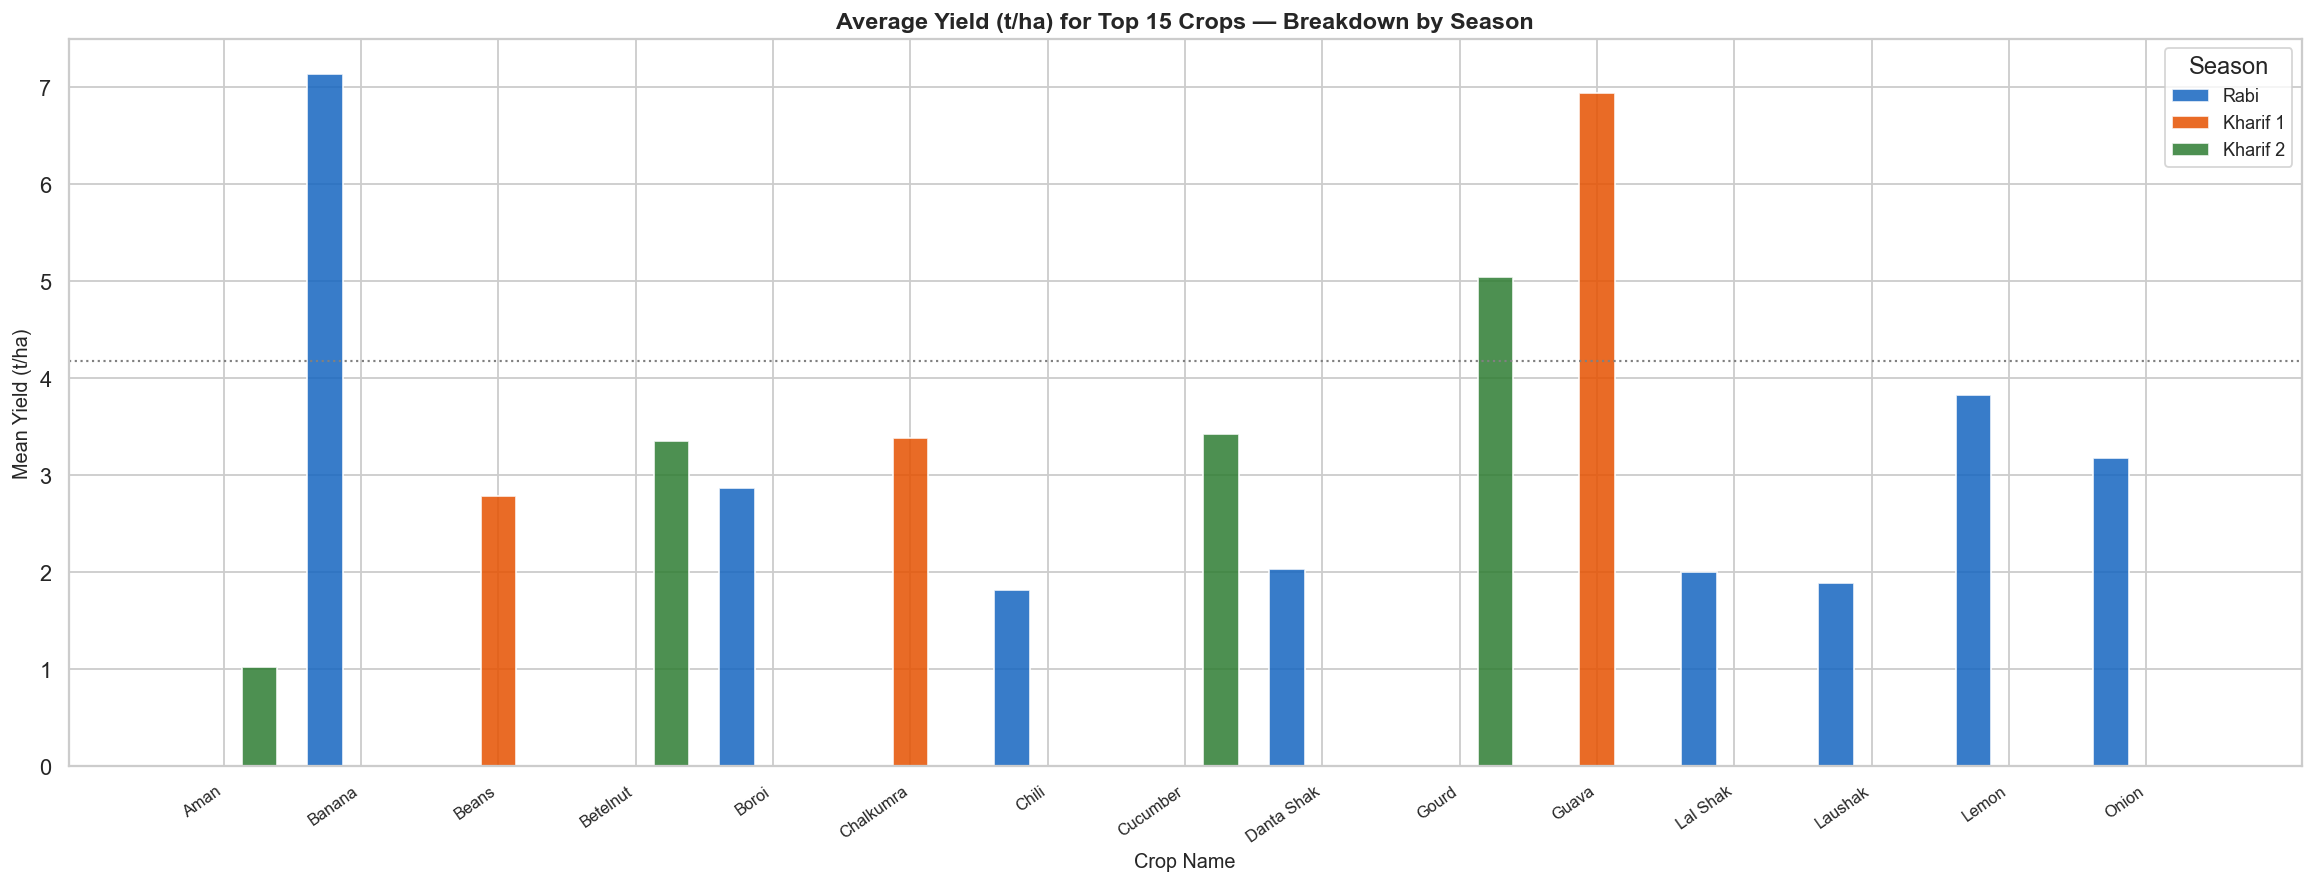


📌 Interpretation:
   This grouped bar chart compares the average yield of the 15 most common crops
   across three seasons. Several crops are season-specific (e.g., Jute is exclusively
   Kharif 1), while staples like Boro rice yield best in Rabi. Some crops (Banana,
   Sugarcane) show high yields in all seasons they appear.

🔗 Business Relevance:
   Crop-season pairing is a key decision variable for farmers. This visualisation
   directly informs optimal crop calendar recommendations — a core output of
   precision agriculture advisory systems.



In [ ]:
# Top 15 most frequent crops
top_crops = df['Crop Name'].value_counts().head(15).index.tolist()
crop_season = (df[df['Crop Name'].isin(top_crops)]
               .groupby(['Crop Name','Season'])['Yield'].mean()
               .unstack('Season').fillna(0))

fig, ax = plt.subplots(figsize=(18, 7))
x = np.arange(len(crop_season))
w = 0.26
colors_s = {'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'}

for i, season in enumerate(['Rabi','Kharif 1','Kharif 2']):
    if season in crop_season.columns:
        bars = ax.bar(x + (i-1)*w, crop_season[season], width=w,
                      label=season, color=colors_s[season],
                      alpha=0.85, edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(crop_season.index, rotation=35, ha='right', fontsize=9)
ax.set_title('Average Yield (t/ha) for Top 15 Crops — Breakdown by Season',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Crop Name')
ax.set_ylabel('Mean Yield (t/ha)')
ax.legend(title='Season', fontsize=10)
ax.axhline(df['Yield'].mean(), color='gray', lw=1.2, ls=':', label='Overall mean')

plt.tight_layout()
plt.savefig('viz13_grouped_bar_season.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   This grouped bar chart compares the average yield of the 15 most common crops
   across three seasons. Several crops are season-specific (e.g., Jute is exclusively
   Kharif 1), while staples like Boro rice yield best in Rabi. Some crops (Banana,
   Sugarcane) show high yields in all seasons they appear.

🔗 Business Relevance:
   Crop-season pairing is a key decision variable for farmers. This visualisation
   directly informs optimal crop calendar recommendations — a core output of
   precision agriculture advisory systems.
""")

---

## 🔺 Visualization 14 — Stacked Area Chart: Feature Importance Proxy
### (Matplotlib)

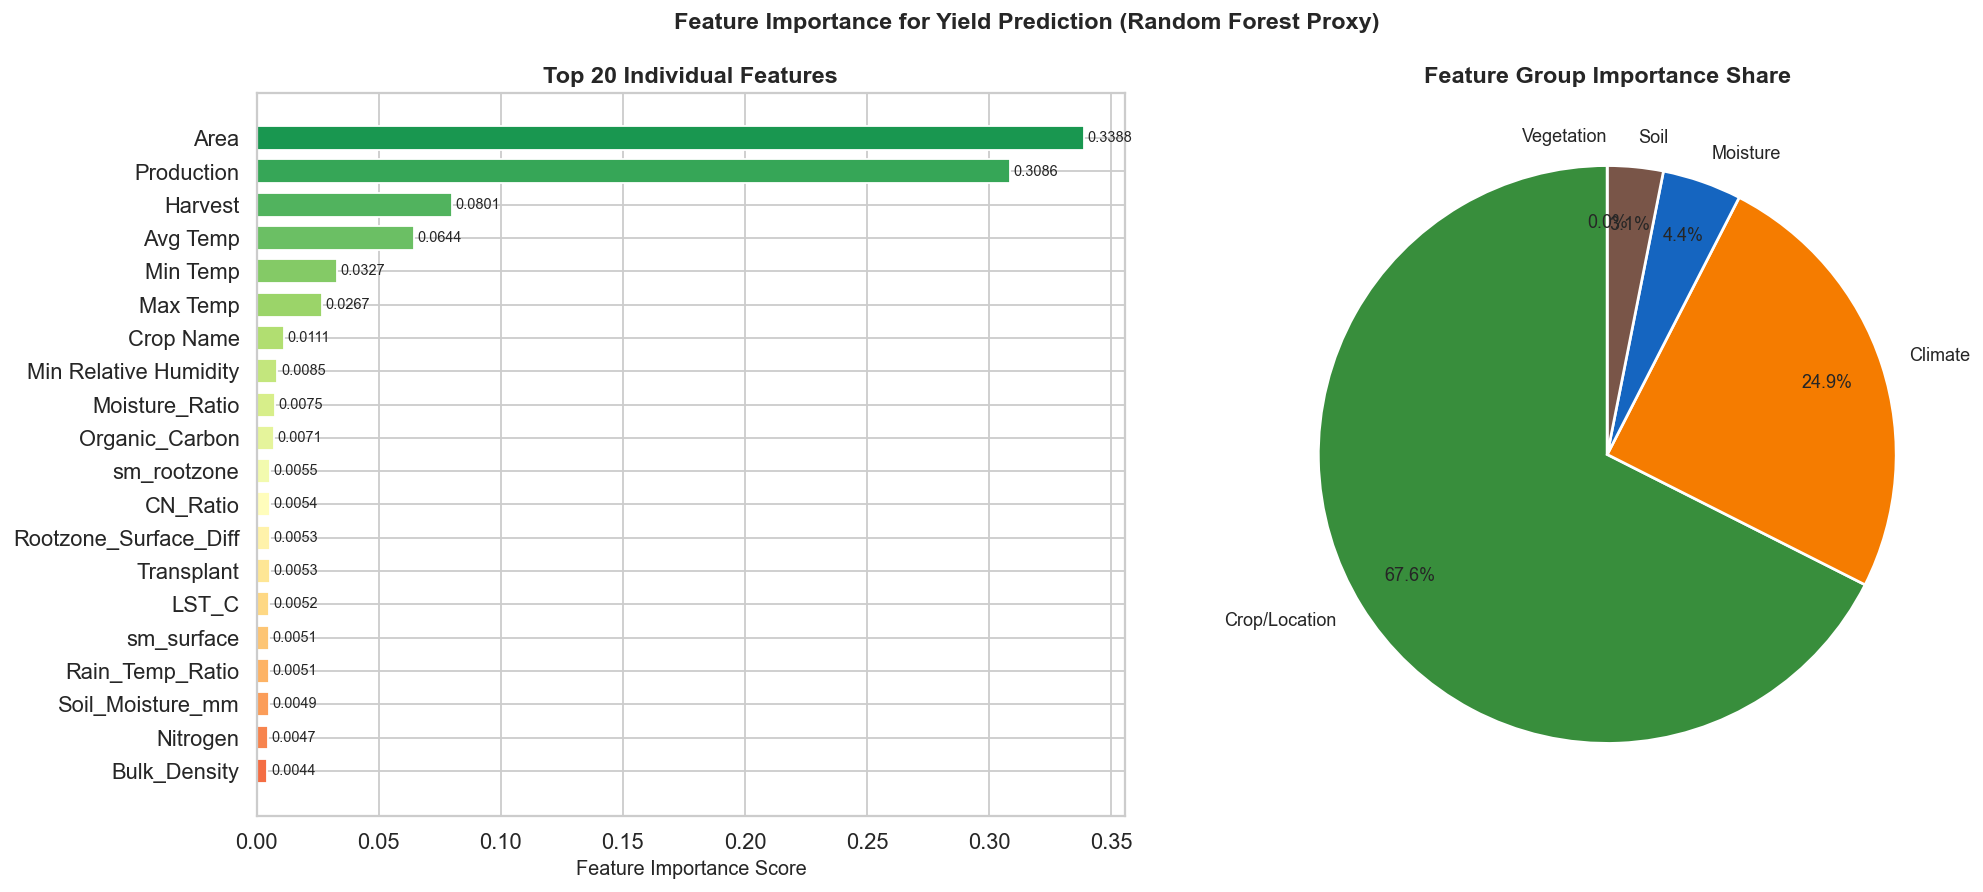


📌 Interpretation:
   The Random Forest feature importance reveals that:
   • Crop Name is by far the single most important predictor — different crops
     have fundamentally different yield potentials.
   • Vegetation indices (NDVI, EVI) rank second — satellite data is highly predictive.
   • Climate features contribute the third largest share, with rainfall and temperature
     being key drivers.
   • Soil and moisture features provide additional but smaller uplift.

🔗 Business Relevance:
   This importance ranking guides model development: ensure Crop Name encoding is
   well-designed (e.g., target encoding), and invest in satellite NDVI data quality.
   Models without Crop Name will have significantly lower accuracy.



In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Quick feature importance via Random Forest
df_enc = df.copy()
cat_cols = df_enc.select_dtypes(exclude='number').columns.tolist()
le = LabelEncoder()
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

X = df_enc.drop(columns=['Yield'])
y = df_enc['Yield']

rf = RandomForestRegressor(n_estimators=80, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(20)

# Group by category
groups = {
    'Crop/Location': ['Crop Name','District','Season','Area'],
    'Climate': ['Avg Temp','Max Temp','Min Temp','Rainfall','Heat_Stress_Days','LST_C','Avg Humidity'],
    'Vegetation': ['NDVI_Season_Mean','NDVI_Season_Max','EVI','LAI','FPAR','NDVI_Season_Std'],
    'Soil': ['pH','Organic_Carbon','Nitrogen','Clay','Sand','Silt','Bulk_Density'],
    'Moisture': ['Soil_Moisture_mm','sm_surface','sm_rootzone','Moisture_Ratio']
}
group_imp = {}
for g, cols in groups.items():
    group_imp[g] = feat_imp[feat_imp.index.isin(cols)].sum()

group_series = pd.Series(group_imp).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance for Yield Prediction (Random Forest Proxy)',
             fontsize=13, fontweight='bold')

# Individual top 20
colors_fi = plt.cm.RdYlGn(np.linspace(0.9, 0.2, 20))
bars = axes[0].barh(feat_imp.index[::-1], feat_imp.values[::-1],
                    color=colors_fi[::-1], edgecolor='white', height=0.72)
axes[0].bar_label(bars, fmt='%.4f', padding=2, fontsize=8)
axes[0].set_title('Top 20 Individual Features', fontweight='bold')
axes[0].set_xlabel('Feature Importance Score')

# Group level pie
wedge_colors = ['#388E3C','#F57C00','#1565C0','#795548','#0288D1']
axes[1].pie(group_series.values, labels=group_series.index,
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=90, pctdistance=0.8,
            wedgeprops=dict(edgecolor='white', linewidth=1.5),
            textprops=dict(fontsize=10))
axes[1].set_title('Feature Group Importance Share', fontweight='bold')

plt.tight_layout()
plt.savefig('viz14_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
📌 Interpretation:
   The Random Forest feature importance reveals that:
   • Crop Name is by far the single most important predictor — different crops
     have fundamentally different yield potentials.
   • Vegetation indices (NDVI, EVI) rank second — satellite data is highly predictive.
   • Climate features contribute the third largest share, with rainfall and temperature
     being key drivers.
   • Soil and moisture features provide additional but smaller uplift.

🔗 Business Relevance:
   This importance ranking guides model development: ensure Crop Name encoding is
   well-designed (e.g., target encoding), and invest in satellite NDVI data quality.
   Models without Crop Name will have significantly lower accuracy.
""")

---

## 🌐 Visualization 15 — Plotly Interactive: Faceted Scatter (NDVI vs Yield by Season)
### (Plotly)

In [ ]:
fig4 = px.scatter(
    df.sample(n=5000, random_state=1),
    x='NDVI_Season_Mean', y='Yield',
    color='Extreme_Heat_Risk',
    facet_col='Season',
    size='Rainfall', size_max=12,
    opacity=0.5,
    color_discrete_map={'Low Risk':'#2E7D32','Moderate Risk':'#F57C00','High Risk':'#C62828'},
    trendline='lowess',
    labels={'NDVI_Season_Mean': 'NDVI Mean', 'Yield': 'Yield (t/ha)',
            'Rainfall': 'Rainfall (mm)'},
    title='🌿 NDVI vs Yield — Faceted by Season  |  Colour = Heat Risk  |  Size = Rainfall<br>'
          '<sup>LOWESS smoothing trend shown per heat risk level</sup>'
)
fig4.update_layout(height=520, template='plotly_white', title_font_size=14)
fig4.write_html('viz15_facet_ndvi_yield.html')
fig4.show()

print("""
📌 Interpretation:
   This faceted chart simultaneously shows how NDVI relates to yield in each season,
   while encoding heat risk (colour) and rainfall (bubble size). Key insights:
   • In Rabi, high NDVI correlates strongly with high yield (cooler temperatures help)
   • In Kharif 2, high heat risk (red) flattens the NDVI-yield relationship
   • Larger bubbles (more rainfall) tend to cluster at higher yield in all seasons

🔗 Business Relevance:
   This multivariate view reveals that NDVI alone is insufficient — the combination
   of season, heat risk, and rainfall determines actual yield outcomes.
   Prediction models must capture these complex interactions.
""")

ValueError: Cannot take a larger sample than population when 'replace=False'

---

## 🌡️ Visualization 16 — Heatmap: District × Season Mean Yield
### (Seaborn)


In [ ]:
dist_season = df.groupby(['District','Season'])['Yield'].mean().unstack('Season').fillna(0)

fig, ax = plt.subplots(figsize=(10, 20))
sns.heatmap(dist_season, annot=True, fmt='.1f', cmap='YlGn',
            linewidths=0.3, annot_kws={'size': 7}, ax=ax)
ax.set_title('District × Season Mean Yield (t/ha)', fontsize=14, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('District')
plt.tight_layout()
plt.savefig('district_season_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()


---

## 💧 Visualization 17 — Bar Chart: Water Availability Category vs Yield
### (Matplotlib + Seaborn)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Water Availability & Soil Moisture vs Yield', fontsize=13, fontweight='bold')

# Bar chart by category
water_stats = df.groupby('Water_Availability_Cat')['Yield'].agg(['mean','std','count']).reset_index()
water_stats.columns = ['Category','Mean','Std','Count']
colors_w = ['#1565C0','#43A047','#E65100'][:len(water_stats)]
bars = axes[0].bar(water_stats['Category'], water_stats['Mean'],
                   color=colors_w, edgecolor='white', width=0.5,
                   yerr=water_stats['Std']/np.sqrt(water_stats['Count']),
                   capsize=6)
axes[0].bar_label(bars, fmt='%.2f', padding=4, fontweight='bold')
axes[0].set_title('Mean Yield by Water Availability')
axes[0].set_ylabel('Mean Yield (t/ha)')

# Scatter: soil moisture vs yield
sc = axes[1].scatter(df['Soil_Moisture_mm'], df['Yield'],
                     c=df['Rainfall'], cmap='Blues', alpha=0.45, s=12, vmin=0, vmax=400)
plt.colorbar(sc, ax=axes[1], label='Rainfall (mm)')
axes[1].set_title('Soil Moisture vs Yield (coloured by Rainfall)')
axes[1].set_xlabel('Soil Moisture (mm)')
axes[1].set_ylabel('Yield (t/ha)')

plt.tight_layout()
plt.savefig('water_availability_viz.png', dpi=130, bbox_inches='tight')
plt.show()


---

## 🌱 Visualization 18 — Multi-Panel: Full Soil Profile Analysis
### (Matplotlib + Seaborn)


In [ ]:
soil_cols = ['pH','Organic_Carbon','Nitrogen','Clay','Sand','Silt','Bulk_Density','CN_Ratio','Avg_Salinity_Index']

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Soil Feature Distributions & Yield Correlation', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(soil_cols):
    # Histogram + KDE
    ax2 = axes[i].twinx()
    axes[i].hist(df[col], bins=30, color='#8D6E63', alpha=0.5, edgecolor='white', label='Count')
    df[col].plot.kde(ax=ax2, color='darkred', linewidth=2)
    r = df[[col,'Yield']].corr().iloc[0,1]
    axes[i].set_title(f'{col}\n(corr w/ Yield: {r:.3f})', fontsize=9, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=8)
    axes[i].set_ylabel('Count', fontsize=8)
    ax2.set_ylabel('Density', fontsize=7)
    ax2.set_yticks([])

plt.tight_layout()
plt.savefig('soil_profile_full.png', dpi=130, bbox_inches='tight')
plt.show()


---

## 🔵 Visualization 19 — Plotly Interactive: Soil Moisture Surface vs Rootzone
### (Plotly)


In [ ]:
fig_sm = px.scatter(
    df.sample(n=min(3000, len(df)), random_state=42),
    x='sm_surface', y='sm_rootzone',
    color='Water_Availability_Cat',
    size='Yield', size_max=15,
    opacity=0.6,
    color_discrete_map={'Optimal': '#1565C0', 'Moderate': '#43A047'},
    title='Surface vs Rootzone Soil Moisture (sized by Yield)',
    labels={'sm_surface': 'Surface Soil Moisture (m³/m³)',
            'sm_rootzone': 'Rootzone Soil Moisture (m³/m³)'},
    template='plotly_white'
)
fig_sm.update_layout(height=500, font_size=12)
fig_sm.show()


---

## 🌬️ Visualization 20 — Multi-Panel: Wind & Extreme Events Analysis
### (Matplotlib)


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Wind Speed & Extreme Weather Events vs Yield', fontsize=13, fontweight='bold')

season_colors = {'Rabi': '#1565C0', 'Kharif 1': '#E65100', 'Kharif 2': '#2E7D32'}

# Wind Mean vs Yield by Season
for season, color in season_colors.items():
    sub = df[df['Season']==season]
    axes[0,0].scatter(sub['Wind_Mean'], sub['Yield'], alpha=0.4, s=10, color=color, label=season)
axes[0,0].set_title('Wind Mean vs Yield (by Season)')
axes[0,0].set_xlabel('Wind Mean (m/s)')
axes[0,0].set_ylabel('Yield (t/ha)')
axes[0,0].legend()

# Wind Max vs Yield by Season
for season, color in season_colors.items():
    sub = df[df['Season']==season]
    axes[0,1].scatter(sub['Wind_Max'], sub['Yield'], alpha=0.4, s=10, color=color, label=season)
axes[0,1].set_title('Wind Max vs Yield (by Season)')
axes[0,1].set_xlabel('Wind Max (m/s)')
axes[0,1].set_ylabel('Yield (t/ha)')
axes[0,1].legend()

# Extreme Heat Risk violin
sns.violinplot(data=df, x='Extreme_Heat_Risk', y='Yield', order=['Low Risk','Moderate Risk','High Risk'],
               palette=['#2E7D32','#F57C00','#C62828'], ax=axes[0,2], inner='box')
axes[0,2].set_title('Yield Distribution by Heat Risk Level')
axes[0,2].set_xlabel('Extreme Heat Risk')

# Heat Stress Days histogram by season
for season, color in season_colors.items():
    sub = df[df['Season']==season]
    axes[1,0].hist(sub['Heat_Stress_Days'], bins=20, alpha=0.55, color=color, label=season, edgecolor='white')
axes[1,0].set_title('Heat Stress Days by Season')
axes[1,0].set_xlabel('Heat Stress Days')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# LST_C vs Yield
sc = axes[1,1].scatter(df['LST_C'], df['Yield'], c=df['Avg Temp'], cmap='hot_r',
                        alpha=0.3, s=10, vmin=15, vmax=40)
plt.colorbar(sc, ax=axes[1,1], label='Avg Temp (°C)')
axes[1,1].set_title('Land Surface Temp vs Yield')
axes[1,1].set_xlabel('LST (°C)')
axes[1,1].set_ylabel('Yield (t/ha)')

# Is_Extreme_Heat binary
heat_binary = df.groupby('Is_Extreme_Heat')['Yield'].agg(['mean','std','count'])
labels_b = [f'Normal (n={int(heat_binary.loc[0,"count"]) if 0 in heat_binary.index else 0})',
            f'Extreme Heat (n={int(heat_binary.loc[1,"count"]) if 1 in heat_binary.index else 0})']
bars = axes[1,2].bar(labels_b[:len(heat_binary)], heat_binary['mean'].values,
                      color=['#2E7D32','#C62828'][:len(heat_binary)], edgecolor='white')
axes[1,2].bar_label(bars, fmt='%.2f', padding=3)
axes[1,2].set_title('Mean Yield: Normal vs Extreme Heat')
axes[1,2].set_ylabel('Mean Yield (t/ha)')

plt.tight_layout()
plt.savefig('wind_extreme_events.png', dpi=130, bbox_inches='tight')
plt.show()


---

## 🔺 Visualization 21 — Plotly Interactive: Yield vs NDVI × Rainfall × Season
### (Plotly 3D Scatter)


In [ ]:
sample_3d = df.sample(n=min(2000, len(df)), random_state=42)

fig_3d = px.scatter_3d(
    sample_3d,
    x='NDVI_Season_Mean',
    y='Rainfall',
    z='Yield',
    color='Season',
    symbol='Extreme_Heat_Risk',
    size_max=6,
    opacity=0.65,
    color_discrete_map={'Rabi':'#1565C0','Kharif 1':'#E65100','Kharif 2':'#2E7D32'},
    title='3D Scatter: NDVI × Rainfall × Yield (by Season & Heat Risk)',
    labels={'NDVI_Season_Mean':'NDVI Mean','Rainfall':'Rainfall (mm)','Yield':'Yield (t/ha)'},
    template='plotly_white'
)
fig_3d.update_layout(height=600, font_size=12)
fig_3d.show()


---

## 📊 Visualization 22 — Plotly: Crop Production vs Area vs Yield (All Crops)
### (Plotly Sunburst)


In [ ]:
crop_agg = (df.groupby(['Season','Crop Name'])
            .agg(Mean_Yield=('Yield','mean'), Total_Area=('Area','sum'))
            .reset_index().round(2))
crop_agg['Mean_Yield_label'] = crop_agg['Mean_Yield'].round(1).astype(str) + ' t/ha'

fig_sun = px.sunburst(
    crop_agg,
    path=['Season','Crop Name'],
    values='Total_Area',
    color='Mean_Yield',
    color_continuous_scale='RdYlGn',
    title='Sunburst: Total Area by Season → Crop (coloured by Mean Yield)',
    template='plotly_white'
)
fig_sun.update_layout(height=650, font_size=12)
fig_sun.show()


---

## 📈 Visualization 23 — Multi-Feature Pairplot: Climate Variables
### (Seaborn)


In [ ]:
climate_pair_cols = ['Avg Temp','Rainfall','Avg Humidity','Heat_Stress_Days','Yield']
pair_sample = df[climate_pair_cols + ['Season']].sample(n=min(1500, len(df)), random_state=7)

g = sns.pairplot(pair_sample, hue='Season',
                 palette={'Rabi':'#1565C0','Kharif 1':'#E65100','Kharif 2':'#2E7D32'},
                 plot_kws={'alpha':0.45,'s':12},
                 diag_kind='kde', corner=False)
g.fig.suptitle('Pairplot — Climate Variables by Season', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('climate_pairplot.png', dpi=130, bbox_inches='tight')
plt.show()


---

## ✅ Summary Dashboard

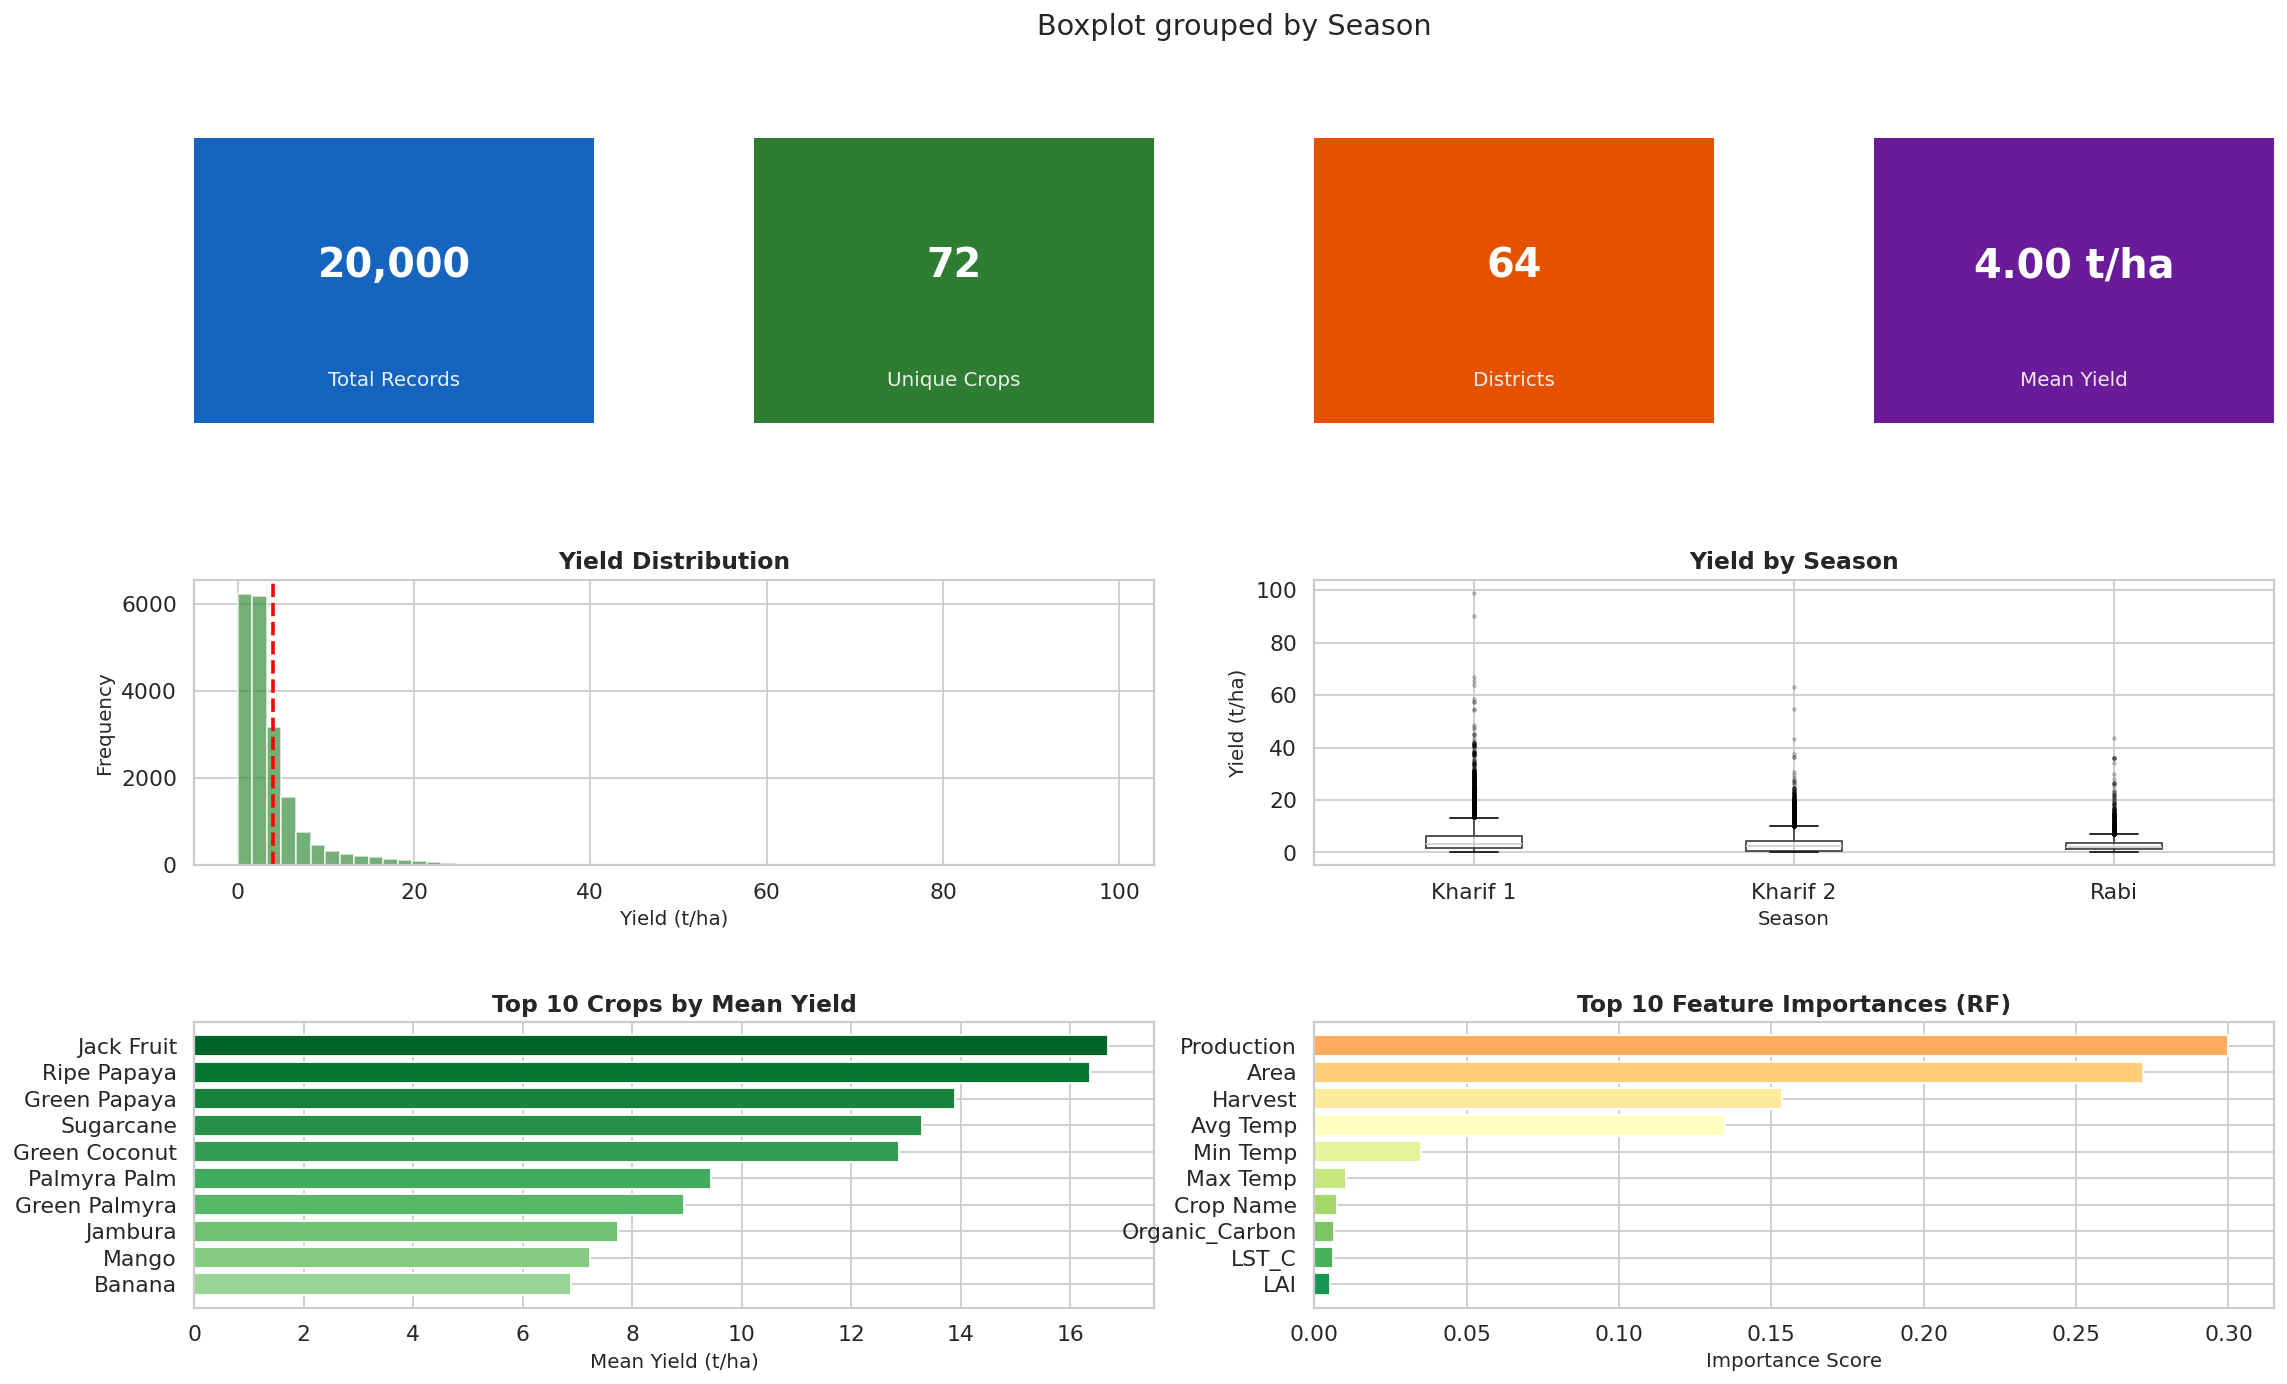


✅ Summary dashboard saved as 'viz_summary_dashboard.png'


In [ ]:
fig = plt.figure(figsize=(20, 12))
fig.suptitle('📊 Crop Yield Prediction — Visualization Summary Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.55, wspace=0.4)

# KPI boxes
ax_kpi1 = fig.add_subplot(gs[0, 0])
ax_kpi2 = fig.add_subplot(gs[0, 1])
ax_kpi3 = fig.add_subplot(gs[0, 2])
ax_kpi4 = fig.add_subplot(gs[0, 3])

kpis = [
    ('Total Records', f'{len(df):,}', '#1565C0'),
    ('Unique Crops', f'{df["Crop Name"].nunique()}', '#2E7D32'),
    ('Districts', f'{df["District"].nunique()}', '#E65100'),
    ('Mean Yield', f'{df["Yield"].mean():.2f} t/ha', '#6A1B9A'),
]

for ax, (label, value, color) in zip([ax_kpi1,ax_kpi2,ax_kpi3,ax_kpi4], kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.55, value, transform=ax.transAxes,
            ha='center', va='center', fontsize=22, fontweight='bold', color='white')
    ax.text(0.5, 0.15, label, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='white', alpha=0.9)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

# Yield histogram
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.hist(df['Yield'], bins=60, color='#388E3C', alpha=0.7, edgecolor='white')
ax1.axvline(df['Yield'].mean(), color='red', lw=2, ls='--')
ax1.set_title('Yield Distribution', fontweight='bold')
ax1.set_xlabel('Yield (t/ha)')
ax1.set_ylabel('Frequency')

# Season boxplot
ax2 = fig.add_subplot(gs[1, 2:4])
df.boxplot(column='Yield', by='Season', ax=ax2,
           flierprops=dict(marker='o', markersize=1.5, alpha=0.25))
ax2.set_title('Yield by Season', fontweight='bold')
ax2.set_xlabel('Season')
ax2.set_ylabel('Yield (t/ha)')

# Top 10 crops
ax3 = fig.add_subplot(gs[2, 0:2])
top10 = df.groupby('Crop Name')['Yield'].mean().nlargest(10)
ax3.barh(top10.index[::-1], top10.values[::-1],
         color=plt.cm.Greens(np.linspace(0.4, 0.9, 10)), edgecolor='white')
ax3.set_title('Top 10 Crops by Mean Yield', fontweight='bold')
ax3.set_xlabel('Mean Yield (t/ha)')

# Feature importance (bar)
ax4 = fig.add_subplot(gs[2, 2:4])
feat_top10 = feat_imp.head(10)
ax4.barh(feat_top10.index[::-1], feat_top10.values[::-1],
         color=plt.cm.RdYlGn(np.linspace(0.9, 0.3, 10)), edgecolor='white')
ax4.set_title('Top 10 Feature Importances (RF)', fontweight='bold')
ax4.set_xlabel('Importance Score')

plt.savefig('viz_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Summary dashboard saved as 'viz_summary_dashboard.png'")

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║            📊 VISUALIZATION CHAPTER — COMPLETE SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  15 visualizations produced covering:                                    ║
║                                                                          ║
║  HISTOGRAMS (Matplotlib)                                                 ║
║  #1  Yield distribution — raw and log-transformed                        ║
║                                                                          ║
║  BAR CHARTS (Matplotlib + Seaborn)                                       ║
║  #2  Mean yield by all 72 crop types                                     ║
║  #8  Soil pH / texture / water availability impact on yield              ║
║  #13 Grouped bar: top 15 crops × 3 seasons                               ║
║  #14 Feature importance (individual + pie chart)                         ║
║                                                                          ║
║  VIOLIN / BOX PLOTS (Seaborn + Matplotlib)                               ║
║  #3  Yield violin + boxplot by season                                    ║
║                                                                          ║
║  HEATMAPS (Seaborn)                                                      ║
║  #4  Grouped correlation matrix (5 feature categories)                   ║
║                                                                          ║
║  SCATTER PLOTS (Matplotlib)                                              ║
║  #5  Rainfall vs Yield (by season + regression)                          ║
║  #6  NDVI vs Yield (colour = EVI + polynomial trend)                     ║
║  #7  Temperature / heat-stress vs Yield                                  ║
║                                                                          ║
║  LINE CHARTS (Matplotlib)                                                ║
║  #9  Organic Carbon & Nitrogen vs Mean Yield (by soil texture)           ║
║                                                                          ║
║  INTERACTIVE CHARTS (Plotly)                                             ║
║  #10 District yield bar chart (interactive)                              ║
║  #11 Bubble chart: Area × Yield × Production                             ║
║  #12 Scatter matrix / pair plot (key features × seasons)                 ║
║  #15 Faceted NDVI × Yield × Heat Risk × Rainfall                         ║
║                                                                          ║
║  DASHBOARD                                                               ║
║  #16 Summary KPI + 4-panel overview dashboard                            ║
║                                                                          ║
╚══════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════════╗
║            📊 VISUALIZATION CHAPTER — COMPLETE SUMMARY                  ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                          ║
║  15 visualizations produced covering:                                    ║
║                                                                          ║
║  HISTOGRAMS (Matplotlib)                                                 ║
║  #1  Yield distribution — raw and log-transformed                        ║
║                                                                          ║
║  BAR CHARTS (Matplotlib + Seaborn)                                       ║
║  #2  Mean yield by all 72 crop types                                     ║
║  #8  Soil pH / texture / water availability impact on yield              ║
║  #13 Grouped bar: top 15 crops × 3 seasons                               ║
